<a href="https://colab.research.google.com/github/manushi0304/CapstoneProject/blob/main/efficient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Colab cell 1: Runtime setup
# (Run this cell first)
# If you're not in Colab you can still run; make sure PyTorch + torchvision are installed.
!nvidia-smi || true

Mon Apr 20 03:22:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Colab cell 2: Install optional helper packages
# thop for FLOPs counting. If already installed, pip will be fast.
!pip install -q thop
!pip install -q onnx
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 18.0 MB/s eta 0:00:00


In [ ]:
"""
Cell 1: Configuration and Setup
================================
Centralized configuration for the NAS+Pruning pipeline.
"""

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision
from torchvision import transforms, datasets, models
import torch.nn.utils.prune as prune
from thop import profile
import matplotlib.pyplot as plt
import time
import copy
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION CLASS
# ============================================================================

class Config:
    """Centralized configuration for reproducibility and easy tuning."""

    # Hardware
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 2
    PIN_MEMORY = True

    # Reproducibility
    SEED = 42

    # Data
    DATA_DIR = './data'
    BATCH_SIZE = 128
    NUM_CLASSES = 10
    VALIDATION_SPLIT = 0.2  # 20% of training data for validation

    # Training - Baseline
    BASELINE_EPOCHS = 50
    BASELINE_LR = 0.1
    BASELINE_MOMENTUM = 0.9
    BASELINE_WEIGHT_DECAY = 5e-4
    BASELINE_MILESTONES = [25,40]  # LR decay at these epochs
    BASELINE_GAMMA = 0.1

    # Training - Fine-tuning after pruning
    FINETUNE_EPOCHS = 30
    FINETUNE_LR = 0.01
    FINETUNE_MOMENTUM = 0.9
    FINETUNE_WEIGHT_DECAY = 5e-4
    FINETUNE_STEP_SIZE = 15
    FINETUNE_GAMMA = 0.5

    # Pruning
    PRUNE_AMOUNT = 0.3  # 30% of filters to prune
    PRUNE_SKIP_DEPTHWISE = True  # Skip depthwise convolutions
    PRUNE_SKIP_FIRST_LAST = True  # Skip first and last layers

    # DARTS Search
    DARTS_INIT_CHANNELS = 16
    DARTS_LAYERS = 6
    DARTS_SEARCH_EPOCHS = 50
    DARTS_SEARCH_BATCHES_PER_EPOCH = 50  # Limit batches per epoch for speed
    DARTS_WEIGHT_LR = 0.025
    DARTS_WEIGHT_MOMENTUM = 0.9
    DARTS_WEIGHT_DECAY = 3e-4
    DARTS_ARCH_LR = 3e-4
    DARTS_ARCH_WEIGHT_DECAY = 1e-3

    # DARTS Final Training
    DARTS_TRAIN_EPOCHS = 50
    DARTS_TRAIN_LR = 0.025
    DARTS_TRAIN_MOMENTUM = 0.9
    DARTS_TRAIN_WEIGHT_DECAY = 3e-4
    DARTS_TRAIN_MILESTONES = [25, 40]
    DARTS_TRAIN_GAMMA = 0.1

    # DARTS + Pruning Combined
    DARTS_PRUNE_AMOUNT = 0.3
    DARTS_FINETUNE_EPOCHS = 30
    DARTS_FINETUNE_LR = 0.01
    DARTS_FINETUNE_WEIGHT_DECAY = 1e-4

    # Evaluation
    INFERENCE_WARMUP_BATCHES = 3
    INFERENCE_MEASURE_BATCHES = 20

    # Paths
    MODEL_DIR = './models'
    RESULTS_DIR = './results'

    @classmethod
    def print_config(cls):
        """Print all configuration parameters."""
        print("=" * 70)
        print("CONFIGURATION")
        print("=" * 70)
        for attr in dir(cls):
            if not attr.startswith('_') and attr.isupper():
                print(f"{attr:30s}: {getattr(cls, attr)}")
        print("=" * 70)


# ============================================================================
# REPRODUCIBILITY SETUP
# ============================================================================

def set_seed(seed: int = 42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Random seed set to {seed}")


# ============================================================================
# DIRECTORY SETUP
# ============================================================================

def setup_directories():
    """Create necessary directories."""
    os.makedirs(Config.MODEL_DIR, exist_ok=True)
    os.makedirs(Config.RESULTS_DIR, exist_ok=True)
    print(f"✅ Directories created: {Config.MODEL_DIR}, {Config.RESULTS_DIR}")


# ============================================================================
# INITIALIZE
# ============================================================================

if __name__ == "__main__":
    Config.print_config()
    set_seed(Config.SEED)
    setup_directories()
    print(f"✅ Using device: {Config.DEVICE}")

CONFIGURATION
BASELINE_EPOCHS               : 50
BASELINE_GAMMA                : 0.1
BASELINE_LR                   : 0.1
BASELINE_MILESTONES           : [25, 40]
BASELINE_MOMENTUM             : 0.9
BASELINE_WEIGHT_DECAY         : 0.0005
BATCH_SIZE                    : 128
DARTS_ARCH_LR                 : 0.0003
DARTS_ARCH_WEIGHT_DECAY       : 0.001
DARTS_FINETUNE_EPOCHS         : 30
DARTS_FINETUNE_LR             : 0.01
DARTS_FINETUNE_WEIGHT_DECAY   : 0.0001
DARTS_INIT_CHANNELS           : 16
DARTS_LAYERS                  : 6
DARTS_PRUNE_AMOUNT            : 0.3
DARTS_SEARCH_BATCHES_PER_EPOCH: 50
DARTS_SEARCH_EPOCHS           : 50
DARTS_TRAIN_EPOCHS            : 50
DARTS_TRAIN_GAMMA             : 0.1
DARTS_TRAIN_LR                : 0.025
DARTS_TRAIN_MILESTONES        : [25, 40]
DARTS_TRAIN_MOMENTUM          : 0.9
DARTS_TRAIN_WEIGHT_DECAY      : 0.0003
DARTS_WEIGHT_DECAY            : 0.0003
DARTS_WEIGHT_LR               : 0.025
DARTS_WEIGHT_MOMENTUM         : 0.9
DATA_DIR                  

In [ ]:
#2
from typing import Tuple
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import transforms, datasets
import numpy as np


# ============================================================================
# DATA TRANSFORMS
# ============================================================================

def get_transforms() -> Tuple[transforms.Compose, transforms.Compose]:
    """
    Get data augmentation transforms for CIFAR-10.

    Returns:
        train_transform: Augmentation for training
        test_transform: Normalization only for testing
    """
    # CIFAR-10 normalization constants
    CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
    CIFAR_STD = (0.2023, 0.1994, 0.2010)

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    return train_transform, test_transform


# ============================================================================
# DATASET LOADING
# ============================================================================

def load_cifar10(config) -> Tuple:
    """
    Load CIFAR-10 with proper train/validation split.

    Args:
        config: Configuration object

    Returns:
        trainloader: Training data loader
        validloader: Validation data loader (from training set)
        testloader: Test data loader
        train_dataset: Full training dataset
        test_dataset: Test dataset
    """
    train_transform, test_transform = get_transforms()

    # Load datasets
    train_dataset = datasets.CIFAR10(
        root=config.DATA_DIR,
        train=True,
        download=True,
        transform=train_transform
    )

    test_dataset = datasets.CIFAR10(
        root=config.DATA_DIR,
        train=False,
        download=True,
        transform=test_transform
    )

    # Create train/validation split for DARTS
    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(config.VALIDATION_SPLIT * num_train))

    # Shuffle indices
    np.random.seed(config.SEED)
    np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]

    # Create samplers
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    # Create data loaders
    trainloader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        sampler=train_sampler,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    validloader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        sampler=valid_sampler,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    testloader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    print(f"✅ CIFAR-10 loaded:")
    print(f"   Training samples: {len(train_idx)}")
    print(f"   Validation samples: {len(valid_idx)}")
    print(f"   Test samples: {len(test_dataset)}")

    return trainloader, validloader, testloader, train_dataset, test_dataset


# ============================================================================
# UTILITY: FULL TRAINING LOADER (NO VALIDATION SPLIT)
# ============================================================================

def get_full_trainloader(train_dataset, config) -> DataLoader:
    """
    Get a data loader for the full training set (for final training).

    Args:
        train_dataset: Training dataset
        config: Configuration object

    Returns:
        DataLoader for full training set
    """
    return DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Removed: from cell_01_config_setup import Config, set_seed
    # Config and set_seed are already available in the global scope
    # from previous cell execution.

    set_seed(Config.SEED)
    trainloader, validloader, testloader, train_dataset, test_dataset = load_cifar10(Config)

    # Verify data loading
    images, labels = next(iter(trainloader))
    print(f"✅ Batch shape: {images.shape}, Labels: {labels.shape}")
    print(f"✅ Image range: [{images.min():.2f}, {images.max():.2f}]")

✅ Random seed set to 42


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
✅ Batch shape: torch.Size([128, 3, 32, 32]), Labels: torch.Size([128])
✅ Image range: [-2.43, 2.75]


In [ ]:
"""
Cell 3: Utility Functions
==========================
Training, evaluation, and metric computation utilities.
"""

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from thop import profile
import copy
from typing import Tuple, Optional


# ============================================================================
# EVALUATION
# ============================================================================

def evaluate(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    criterion: Optional[nn.Module] = None
) -> Tuple[float, float]:
    """
    Evaluate model on a dataset.

    Args:
        model: PyTorch model
        loader: Data loader
        device: Device to run on
        criterion: Loss function (defaults to CrossEntropyLoss)

    Returns:
        avg_loss: Average loss
        accuracy: Accuracy percentage
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total

    return avg_loss, accuracy


# ============================================================================
# TRAINING
# ============================================================================

def train_epoch(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    criterion: Optional[nn.Module] = None,
    max_batches: Optional[int] = None
) -> Tuple[float, float]:
    """
    Train model for one epoch.

    Args:
        model: PyTorch model
        loader: Data loader
        optimizer: Optimizer
        device: Device to run on
        criterion: Loss function
        max_batches: Maximum number of batches (for limiting in DARTS search)

    Returns:
        avg_loss: Average training loss
        accuracy: Training accuracy percentage
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total if total > 0 else 0.0
    accuracy = 100.0 * correct / total if total > 0 else 0.0

    return avg_loss, accuracy


def train_model(
    model: nn.Module,
    trainloader: torch.utils.data.DataLoader,
    testloader: torch.utils.data.DataLoader,
    config,
    epochs: int,
    lr: float,
    save_path: Optional[str] = None,
    verbose: bool = True
) -> nn.Module:
    """
    Complete training loop with evaluation and checkpointing.

    Args:
        model: PyTorch model
        trainloader: Training data loader
        testloader: Test data loader
        config: Configuration object
        epochs: Number of epochs
        lr: Learning rate
        save_path: Path to save best model
        verbose: Print progress

    Returns:
        Trained model
    """
    device = config.DEVICE
    model = model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=config.BASELINE_MOMENTUM,
        weight_decay=config.BASELINE_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.BASELINE_MILESTONES,
        gamma=config.BASELINE_GAMMA
    )

    criterion = nn.CrossEntropyLoss()
    best_acc = 0.0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_acc = train_epoch(model, trainloader, optimizer, device, criterion)

        # Evaluate
        val_loss, val_acc = evaluate(model, testloader, device, criterion)

        # Update learning rate
        scheduler.step()

        if verbose:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            if save_path:
                torch.save(best_model_state, save_path)
                if verbose:
                    print(f"   ✅ Best model saved (acc: {best_acc:.2f}%) Kishan")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model


# ============================================================================
# METRICS
# ============================================================================

def count_parameters(model: nn.Module) -> Tuple[int, int]:
    """
    Count total and non-zero parameters.

    Args:
        model: PyTorch model

    Returns:
        total_params: Total number of parameters
        nonzero_params: Number of non-zero parameters
    """
    total = sum(p.numel() for p in model.parameters())
    nonzero = sum(torch.count_nonzero(p).item() for p in model.parameters())
    return total, nonzero


def measure_flops(
    model: nn.Module,
    input_size: Tuple[int, ...] = (1, 3, 32, 32)
) -> Tuple[int, int]:
    """
    Measure FLOPs and parameters using thop.

    Args:
        model: PyTorch model
        input_size: Input tensor size

    Returns:
        macs: Multiply-accumulate operations
        params: Number of parameters
    """
    model_cpu = copy.deepcopy(model).cpu()
    model_cpu.eval()

    dummy_input = torch.randn(input_size)

    try:
        macs, params = profile(model_cpu, inputs=(dummy_input,), verbose=False)
        return int(macs), int(params)
    except Exception as e:
        print(f"⚠️  FLOPs measurement failed: {e}")
        return 0, 0


def measure_inference_time(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    warmup_batches: int = 3,
    measure_batches: int = 20
) -> float:
    """
    Measure average per-image inference time.

    Args:
        model: PyTorch model
        loader: Data loader
        device: Device to run on
        warmup_batches: Number of warmup iterations
        measure_batches: Number of batches to measure

    Returns:
        Per-image inference time in seconds
    """
    model.eval()

    # Warmup
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= warmup_batches:
                break
            images = images.to(device)
            _ = model(images)

    # Measure
    timings = []
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= measure_batches:
                break
            images = images.to(device)

            # Synchronize GPU
            if device.type == 'cuda':
                torch.cuda.synchronize()

            start = time.time()
            _ = model(images)

            if device.type == 'cuda':
                torch.cuda.synchronize()

            end = time.time()
            timings.append(end - start)

    if len(timings) == 0:
        return float('nan')

    avg_batch_time = sum(timings) / len(timings)
    per_image_time = avg_batch_time / loader.batch_size

    return per_image_time


def collect_metrics(
    model: nn.Module,
    testloader: torch.utils.data.DataLoader,
    config,
    label: str
) -> dict:
    """
    Collect all metrics for a model.

    Args:
        model: PyTorch model
        testloader: Test data loader
        config: Configuration object
        label: Model label for identification

    Returns:
        Dictionary with all metrics
    """
    device = config.DEVICE
    model = model.to(device)

    # Evaluate
    val_loss, val_acc = evaluate(model, testloader, device)

    # Count parameters
    total_params, nonzero_params = count_parameters(model)

    # Measure FLOPs
    macs, params_thop = measure_flops(model)

    # Measure inference time
    inf_time = measure_inference_time(
        model, testloader, device,
        warmup_batches=config.INFERENCE_WARMUP_BATCHES,
        measure_batches=config.INFERENCE_MEASURE_BATCHES
    )

    return {
        'label': label,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'total_params': total_params,
        'nonzero_params': nonzero_params,
        'macs': macs,
        'params_thop': params_thop,
        'inf_time_ms': inf_time * 1000
    }


def print_metrics(metrics: dict):
    """Pretty print metrics dictionary."""
    print(f"\n{'='*70}")
    print(f"Metrics for: {metrics['label']}")
    print(f"{'='*70}")
    print(f"Validation Loss:     {metrics['val_loss']:.4f}")
    print(f"Validation Accuracy: {metrics['val_acc']:.2f}%")
    print(f"Total Parameters:    {metrics['total_params']:,}")
    print(f"Nonzero Parameters:  {metrics['nonzero_params']:,}")
    print(f"MACs:                {metrics['macs']:,}")
    print(f"Inference Time:      {metrics['inf_time_ms']:.2f} ms/image")
    print(f"{'='*70}\n")


# ============================================================================
# MAIN EXECUTION (TEST)
# ============================================================================

if __name__ == "__main__":
    # from cell_01_config_setup import Config, set_seed  # Removed this line
    # from cell_02_data_loading import load_cifar10 # Removed this line

    set_seed(Config.SEED)
    _, _, testloader, _, _ = load_cifar10(Config)

    # Test with a simple model
    model = torch.nn.Sequential(
        torch.nn.Conv2d(3, 16, 3, padding=1),
        torch.nn.ReLU(),
        torch.nn.AdaptiveAvgPool2d(1),
        torch.nn.Flatten(),
        torch.nn.Linear(16, 10)
    )

    metrics = collect_metrics(model, testloader, Config, "Test Model")
    print_metrics(metrics)

✅ Random seed set to 42
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

Metrics for: Test Model
Validation Loss:     2.3649
Validation Accuracy: 11.28%
Total Parameters:    618
Nonzero Parameters:  618
MACs:                458,928
Inference Time:      0.00 ms/image



In [ ]:
"""
Cell 4: Baseline Model - EfficientNet_b0
=====================================
Train baseline efficientnet_b0 on CIFAR-10.
"""

import torch
import torch.nn as nn
from torchvision import models
import os


# ============================================================================
# MODEL DEFINITION
# ============================================================================

def get_efficientnet_b0(num_classes: int = 10, pretrained: bool = True) -> nn.Module:
    """
    Get efficientnet_b0 adapted for CIFAR-10.

    Args:
        num_classes: Number of output classes
        pretrained: Use ImageNet pretrained weights

    Returns:
        efficientnet_b0 model
    """
    model = models.efficientnet_b0(weights="IMAGENET1K_V1" if pretrained else None)


    # Adapt classifier for CIFAR-10
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model


# ============================================================================
# TRAINING
# ============================================================================

def train_baseline(config, trainloader, testloader, save_path: str = None):
    """
    Train baseline efficientnet_b0 model.

    Args:
        config: Configuration object
        trainloader: Training data loader
        testloader: Test data loader
        save_path: Path to save trained model

    Returns:
        Trained model
    """
    print("\n" + "="*70)
    print("TRAINING BASELINE MODEL (efficientnet_b0)")
    print("="*70)

    # Create model
    model = get_efficientnet_b0(
        num_classes=config.NUM_CLASSES,
        pretrained=True
    )
    model = model.to(config.DEVICE)

    # Setup optimizer and scheduler
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=config.BASELINE_LR,
        momentum=config.BASELINE_MOMENTUM,
        weight_decay=config.BASELINE_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.BASELINE_MILESTONES,
        gamma=config.BASELINE_GAMMA
    )

    criterion = nn.CrossEntropyLoss()

    # Training loop
    best_acc = 0.0
    best_model_state = None

    for epoch in range(1, config.BASELINE_EPOCHS + 1):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in trainloader:
            images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss = train_loss / train_total
        train_acc = 100.0 * train_correct / train_total

        # Evaluate
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = 100.0 * val_correct / val_total

        # Update scheduler
        scheduler.step()

        # Print progress
        print(f"Epoch {epoch:3d}/{config.BASELINE_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict().copy()
            if save_path:
                torch.save(best_model_state, save_path)
                print(f"   ✅ Best model saved (acc: {best_acc:.2f}%) Kishan")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\n✅ Baseline training complete. Best accuracy: {best_acc:.2f}%")

    return model


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # from cell_01_config_setup import Config, set_seed, setup_directories
    # from cell_02_data_loading import load_cifar10, get_full_trainloader
    # from cell_03_utilities import collect_metrics, print_metrics

    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data (use full training set for baseline)
    _, _, testloader, train_dataset, _ = load_cifar10(Config)
    trainloader = get_full_trainloader(train_dataset, Config)

    # Train baseline
    save_path = os.path.join(Config.MODEL_DIR, 'baseline_efficientnet_b0.pth')
    baseline_model = train_baseline(Config, trainloader, testloader, save_path)

    # Collect and print metrics
    metrics = collect_metrics(baseline_model, testloader, Config, "Baseline efficientnet_b0")
    print_metrics(metrics)

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

TRAINING BASELINE MODEL (efficientnet_b0)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 216MB/s]


Epoch   1/50 | Train Loss: 2.3852 | Train Acc: 19.19% | Val Loss: 1.9901 | Val Acc: 21.12%
   ✅ Best model saved (acc: 21.12%) Kishan
Epoch   2/50 | Train Loss: 1.8728 | Train Acc: 28.43% | Val Loss: 1.9787 | Val Acc: 24.18%
   ✅ Best model saved (acc: 24.18%) Kishan
Epoch   3/50 | Train Loss: 1.7771 | Train Acc: 33.01% | Val Loss: 1.7716 | Val Acc: 35.59%
   ✅ Best model saved (acc: 35.59%) Kishan
Epoch   4/50 | Train Loss: 1.6863 | Train Acc: 36.90% | Val Loss: 1.6117 | Val Acc: 38.94%
   ✅ Best model saved (acc: 38.94%) Kishan
Epoch   5/50 | Train Loss: 1.5583 | Train Acc: 42.79% | Val Loss: 1.4160 | Val Acc: 46.44%
   ✅ Best model saved (acc: 46.44%) Kishan
Epoch   6/50 | Train Loss: 1.3837 | Train Acc: 50.13% | Val Loss: 1.2063 | Val Acc: 57.15%
   ✅ Best model saved (acc: 57.15%) Kishan
Epoch   7/50 | Train Loss: 1.2585 | Train Acc: 55.08% | Val Loss: 1.2506 | Val Acc: 54.57%
Epoch   8/50 | Train Loss: 1.1603 | Train Acc: 58.72% | Val Loss: 1.1906 | Val Acc: 58.29%
   ✅ Best mode

In [ ]:
"""
Cell 5: Physical Pruning – EfficientNet-B0 (FINAL ROBUST VERSION)
=================================================================
• Auto-detects Expansion/Depthwise/Projection layers.
• Skips MBConv1 and risky blocks to prevent crashes.
• Rebuilds the model physically for real parameter reduction.
"""

import torch
import torch.nn as nn
import copy
from functools import reduce

# ============================================================================
# 1. HELPERS (Structure Analysis)
# ============================================================================
def get_module_by_name(model, path):
    return reduce(getattr, path.split('.'), model)

def set_module_by_name(model, path, new_module):
    names = path.split('.')
    parent = reduce(getattr, names[:-1], model)
    setattr(parent, names[-1], new_module)

def analyze_block_structure(layer):
    """
    Returns (ExpandConv, DepthwiseConv, ProjectConv) named tuples
    by analyzing kernel sizes and order.
    """
    convs = []
    for name, m in layer.named_modules():
        if isinstance(m, nn.Conv2d):
            convs.append((name, m))

    if not convs: return None, None, None

    # 1. Locate Depthwise Conv (Kernel > 1 or Groups > 1)
    dw_idx = -1
    for i, (name, m) in enumerate(convs):
        if m.kernel_size != (1, 1) or m.groups == m.in_channels:
            dw_idx = i
            break

    if dw_idx == -1: return None, None, None # No DW conv found

    # 2. Locate Expansion (1x1 Conv immediately BEFORE DW)
    exp_info = convs[dw_idx - 1] if dw_idx > 0 else None

    # 3. Locate Projection (Last 1x1 Conv)
    proj_info = convs[-1]

    # Validation: Expansion must be 1x1
    if exp_info and exp_info[1].kernel_size != (1, 1):
        exp_info = None # It wasn't an expansion layer (maybe MBConv1)

    return exp_info, convs[dw_idx], proj_info

# ============================================================================
# 2. MASK EXTRACTION (Safe & Validated)
# ============================================================================
def extract_efficientnet_masks(model, prune_amount=0.3):
    masks = {}
    print(f"\n🔍 Analyzing channels to prune (Target: {prune_amount*100}%)")

    for i, layer in enumerate(model.features):
        if i == 0 or i >= len(model.features) - 1: continue

        exp_info, dw_info, proj_info = analyze_block_structure(layer)

        # We need all three parts to perform internal pruning
        if not exp_info or not dw_info or not proj_info:
            continue

        name_exp, mod_exp = exp_info
        name_proj, mod_proj = proj_info

        # CRITICAL VALIDATION:
        # The output of Expansion must match Input of Projection (Internal Channels)
        if mod_exp.out_channels != mod_proj.in_channels:
            continue

        # If valid, calculate mask
        weight = mod_exp.weight.data.abs()
        l1_norm = weight.view(weight.size(0), -1).sum(dim=1)
        keep_count = max(int(weight.size(0) * (1 - prune_amount)), 1)
        threshold = torch.topk(l1_norm, keep_count).values.min()
        mask = (l1_norm >= threshold).cpu().numpy()

        masks[f"features.{i}"] = mask

    print(f"✅ Found {len(masks)} valid blocks to prune.")
    return masks

# ============================================================================
# 3. PHYSICAL RECONSTRUCTION (Rebuilds Layers)
# ============================================================================
def rebuild_mbconv_block_robust(layer, mask):
    new_layer = copy.deepcopy(layer)
    out_channels_new = int(mask.sum())

    # Analyze again to find the exact modules to replace
    exp_info, dw_info, proj_info = analyze_block_structure(new_layer)

    name_exp, old_exp = exp_info
    name_dw, old_dw = dw_info
    name_proj, old_proj = proj_info

    # 1. Prune Expansion
    new_exp = nn.Conv2d(old_exp.in_channels, out_channels_new, 1, 1, 0, bias=False)
    new_exp.weight.data = old_exp.weight.data[mask].clone()
    set_module_by_name(new_layer, name_exp, new_exp)

    # 2. Prune Depthwise
    new_dw = nn.Conv2d(out_channels_new, out_channels_new,
                       old_dw.kernel_size, old_dw.stride, old_dw.padding,
                       groups=out_channels_new, bias=False)
    new_dw.weight.data = old_dw.weight.data[mask].clone()
    set_module_by_name(new_layer, name_dw, new_dw)

    # 3. Prune Projection
    new_proj = nn.Conv2d(out_channels_new, old_proj.out_channels, 1, 1, 0, bias=False)
    new_proj.weight.data = old_proj.weight.data[:, mask, :, :].clone()
    set_module_by_name(new_layer, name_proj, new_proj)

    # 4. Handle BNs (Search for BNs immediately following these convs)
    all_modules = list(new_layer.named_modules())

    def replace_bn(conv_name, new_channels):
        idx = -1
        for k, (n, m) in enumerate(all_modules):
            if n == conv_name: idx = k; break

        if idx != -1 and idx + 1 < len(all_modules):
            bn_name, bn_mod = all_modules[idx+1]
            if isinstance(bn_mod, nn.BatchNorm2d):
                new_bn = nn.BatchNorm2d(new_channels)
                new_bn.weight.data = bn_mod.weight.data[mask].clone()
                new_bn.bias.data = bn_mod.bias.data[mask].clone()
                new_bn.running_mean = bn_mod.running_mean[mask].clone()
                new_bn.running_var = bn_mod.running_var[mask].clone()
                set_module_by_name(new_layer, bn_name, new_bn)

    replace_bn(name_exp, out_channels_new)
    replace_bn(name_dw, out_channels_new)

    # 5. Handle SE (if strictly between DW and Proj)
    for name, m in new_layer.named_modules():
        if isinstance(m, nn.Conv2d) and name not in [name_exp, name_dw, name_proj]:
            if m.in_channels == old_exp.out_channels: # SE Reduce
                new_se = nn.Conv2d(out_channels_new, m.out_channels, 1)
                set_module_by_name(new_layer, name, new_se)
            elif m.out_channels == old_exp.out_channels: # SE Expand
                new_se = nn.Conv2d(m.in_channels, out_channels_new, 1)
                set_module_by_name(new_layer, name, new_se)

    return new_layer

def build_physically_pruned_efficientnet(model, masks):
    print("\n🔨 Building Physically Pruned Model...")
    new_model = copy.deepcopy(model)

    for key, mask in masks.items():
        layer_idx = int(key.split('.')[1])
        try:
            old_block = new_model.features[layer_idx]
            new_block = rebuild_mbconv_block_robust(old_block, mask)
            new_model.features[layer_idx] = new_block
        except Exception as e:
            print(f"⚠️ Failed to rebuild Block {layer_idx}: {e}")

    return new_model

# ============================================================================
# 4. MAIN WRAPPER (This matches your existing call)
# ============================================================================
def prune_model(model, config, prune_amount=None):
    if prune_amount is None:
        prune_amount = config.PRUNE_AMOUNT

    masks = extract_efficientnet_masks(model, prune_amount)

    if not masks:
        print("⚠️ No layers found to prune.")
        return model, {}

    pruned_model = build_physically_pruned_efficientnet(model, masks)

    orig_params = sum(p.numel() for p in model.parameters())
    new_params = sum(p.numel() for p in pruned_model.parameters())
    print(f"\n📊 Pruning Complete:")
    print(f"   Original Params: {orig_params:,}")
    print(f"   Pruned Params:   {new_params:,}")
    print(f"   Reduction:       {100 * (1 - new_params/orig_params):.2f}%")

    return pruned_model, masks

In [ ]:
# ==============================================================================
# 1. Define the missing Fine-Tuning Wrapper
# ==============================================================================
def finetune_pruned_model(model, trainloader, testloader, config, save_path):
    """
    Fine-tunes the pruned model using parameters from Config.
    Wraps the standard train_model function.
    """
    print("\n" + "="*70)
    print("FINETUNING PRUNED EFFICIENTNET")
    print("="*70)

    # We use the specific FINETUNE parameters (usually lower LR)
    return train_model(
        model,
        trainloader,
        testloader,
        config,
        epochs=config.FINETUNE_EPOCHS,
        lr=config.FINETUNE_LR,
        save_path=save_path
    )

# ==============================================================================
# 2. Execution Logic
# ==============================================================================

# A. Ensure Data is Loaded (if not already in memory)
if 'trainloader' not in locals() or 'testloader' not in locals():
    print("🔄 Reloading data loaders...")
    trainloader, validloader, testloader, _, _ = load_cifar10(Config)

# B. Load Baseline Model
# Note: Ensure 'baseline_efficientnet_b0.pth' exists in your ./models folder
baseline_path = './models/baseline_efficientnet_b0.pth'

if not os.path.exists(baseline_path):
    print(f"⚠️  Baseline model not found at {baseline_path}")
    print("    Training baseline from scratch (this might take a while)...")
    # If no file, train a fresh baseline
    trainloader_full = get_full_trainloader(train_dataset, Config) # Use full set for baseline
    baseline = train_baseline(Config, trainloader_full, testloader, baseline_path)
else:
    print(f"✅ Loading baseline from {baseline_path}")
    baseline = get_efficientnet_b0(num_classes=10)
    baseline.load_state_dict(torch.load(baseline_path, map_location=Config.DEVICE))
    baseline = baseline.to(Config.DEVICE)

# C. Prune (Physical Pruning)
# This uses the new physical pruning logic you just added to Cell 5
pruned, masks = prune_model(baseline, Config)

# D. Fine-tune
save_path = './models/pruned_efficientnet_b0_finetuned.pth'
pruned = finetune_pruned_model(pruned, trainloader, testloader, Config, save_path)

print("\n✅ Process Complete. Pruned model saved.")

✅ Loading baseline from ./models/baseline_efficientnet_b0.pth

🔍 Analyzing channels to prune (Target: 30.0%)
✅ Found 1 valid blocks to prune.

🔨 Building Physically Pruned Model...

📊 Pruning Complete:
   Original Params: 4,020,358
   Pruned Params:   3,805,146
   Reduction:       5.35%

FINETUNING PRUNED EFFICIENTNET
Epoch   1/30 | Train Loss: 0.4901 | Train Acc: 83.18% | Val Loss: 0.5063 | Val Acc: 82.33%
   ✅ Best model saved (acc: 82.33%) Kishan
Epoch   2/30 | Train Loss: 0.4965 | Train Acc: 82.74% | Val Loss: 0.4929 | Val Acc: 82.62%
   ✅ Best model saved (acc: 82.62%) Kishan
Epoch   3/30 | Train Loss: 0.4984 | Train Acc: 82.78% | Val Loss: 0.4964 | Val Acc: 82.87%
   ✅ Best model saved (acc: 82.87%) Kishan
Epoch   4/30 | Train Loss: 0.4950 | Train Acc: 82.83% | Val Loss: 0.4934 | Val Acc: 82.87%
Epoch   5/30 | Train Loss: 0.4921 | Train Acc: 82.93% | Val Loss: 0.4894 | Val Acc: 83.02%
   ✅ Best model saved (acc: 83.02%) Kishan
Epoch   6/30 | Train Loss: 0.4889 | Train Acc: 83.10%

In [ ]:
"""
Cell 6: DARTS Operations
=========================
Differentiable Architecture Search operations and MixedOp.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================================
# BASIC OPERATIONS
# ============================================================================

class SepConv(nn.Module):
    """Separable Convolution."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            # First depthwise-separable conv
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_in, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_in, affine=affine),
            nn.ReLU(inplace=False),
            # Second depthwise-separable conv (stride=1 to maintain size)
            nn.Conv2d(C_in, C_in, kernel_size, 1, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )

    def forward(self, x):
        return self.op(x)


class DilConv(nn.Module):
    """Dilated Convolution."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation=2, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding,
                     dilation=dilation, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )

    def forward(self, x):
        return self.op(x)


class Identity(nn.Module):
    """Identity or 1x1 conv if channels don't match."""

    def __init__(self, C_in, C_out, stride):
        super().__init__()
        self.stride = stride
        if C_in != C_out or stride != 1:
            self.adjust = nn.Sequential(
                nn.Conv2d(C_in, C_out, 1, stride=stride, bias=False),
                nn.BatchNorm2d(C_out)
            )
        else:
            self.adjust = None

    def forward(self, x):
        if self.adjust is None:
            return x
        return self.adjust(x)


class PoolBN(nn.Module):
    """Max pooling followed by 1x1 conv."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding):
        super().__init__()
        self.op = nn.Sequential(
            nn.MaxPool2d(kernel_size, stride=stride, padding=padding),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out)
        )

    def forward(self, x):
        return self.op(x)


# ============================================================================
# OPERATIONS FACTORY
# ============================================================================

def get_operations(C_in, C_out, stride):
    """
    Get dictionary of available operations.

    Args:
        C_in: Input channels
        C_out: Output channels
        stride: Stride for convolutions

    Returns:
        Dictionary mapping operation names to modules
    """
    return {
        'sep_3x3': SepConv(C_in, C_out, 3, stride, 1),
        'sep_5x5': SepConv(C_in, C_out, 5, stride, 2),
        'dil_3x3': DilConv(C_in, C_out, 3, stride, 2, dilation=2),
        'identity': Identity(C_in, C_out, stride),
        'max_pool': PoolBN(C_in, C_out, 3, stride, 1)
    }


# ============================================================================
# MIXED OPERATION (FIXED)
# ============================================================================

class MixedOp(nn.Module):
    """
    Mixed operation: weighted sum of candidate operations.
    FIXED: Properly handles spatial dimension mismatches.
    """

    def __init__(self, C_in, C_out, stride):
        super().__init__()
        self._ops = nn.ModuleList()
        self.op_names = []

        operations = get_operations(C_in, C_out, stride)
        for name, op in operations.items():
            self._ops.append(op)
            self.op_names.append(name)

        self.n_ops = len(self._ops)

    def forward(self, x, weights):
        """
        Forward pass with weighted combination of operations.

        Args:
            x: Input tensor
            weights: Softmax weights for each operation

        Returns:
            Weighted sum of operation outputs
        """
        # Compute all operation outputs
        outputs = []
        target_size = None

        for op in self._ops:
            out = op(x)
            outputs.append(out)

            # Determine target spatial size (from first operation)
            if target_size is None:
                target_size = out.shape[2:]

        # Align all outputs to target size
        aligned_outputs = []
        for out in outputs:
            if out.shape[2:] != target_size:
                # Interpolate to match target size
                out = F.interpolate(out, size=target_size, mode='bilinear', align_corners=False)
            aligned_outputs.append(out)

        # Weighted sum
        result = sum(w * out for w, out in zip(weights, aligned_outputs))

        return result


# ============================================================================
# TESTING
# ============================================================================

if __name__ == "__main__":
    import torch

    # Test individual operations
    print("Testing DARTS operations...")

    x = torch.randn(2, 16, 32, 32)

    ops = get_operations(C_in=16, C_out=32, stride=2)

    for name, op in ops.items():
        out = op(x)
        print(f"  {name:15s}: {x.shape} -> {out.shape}")

    # Test MixedOp
    print("\nTesting MixedOp...")
    mixed_op = MixedOp(C_in=16, C_out=32, stride=2)
    weights = F.softmax(torch.randn(mixed_op.n_ops), dim=0)
    out = mixed_op(x, weights)
    print(f"  MixedOp: {x.shape} -> {out.shape}")

    print("\n✅ All operations working correctly")

Testing DARTS operations...
  sep_3x3        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  sep_5x5        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  dil_3x3        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  identity       : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  max_pool       : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])

Testing MixedOp...
  MixedOp: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])

✅ All operations working correctly


In [ ]:
"""
Cell 7: DARTS Search Network
=============================
Network for architecture search with alpha parameters.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
# from cell_06_darts_ops import MixedOp, get_operations # Removed this line


# ============================================================================
# SEARCH NETWORK
# ============================================================================

class DARTSSearchNetwork(nn.Module):
    """
    Network for DARTS architecture search.
    Uses MixedOp layers with learnable architecture parameters (alphas).
    """

    def __init__(self, init_channels=16, num_classes=10, layers=6):
        super().__init__()

        self.init_channels = init_channels
        self.num_classes = num_classes
        self.num_layers = layers

        # Stem convolution
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels)
        )

        # Build layers with MixedOps
        self.layers = nn.ModuleList()
        C_curr = init_channels

        for i in range(layers):
            # Downsample at 1/3 and 2/3 through network
            stride = 2 if i in [layers // 3, 2 * layers // 3] else 1

            # Increase channels after downsampling
            C_out = C_curr if stride == 1 else C_curr * 2

            layer = MixedOp(C_curr, C_out, stride)
            self.layers.append(layer)

            C_curr = C_out

        # Classification head
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

        # Architecture parameters (alphas)
        self.alphas = nn.ParameterList()
        for i in range(layers):
            # Initialize alphas with small random values
            n_ops = len(get_operations(1, 1, 1))
            alpha = nn.Parameter(1e-3 * torch.randn(n_ops))
            self.alphas.append(alpha)

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize network weights."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """Forward pass through search network."""
        x = self.stem(x)

        for i, layer in enumerate(self.layers):
            # Get softmax weights for this layer's operations
            weights = F.softmax(self.alphas[i], dim=0)
            x = layer(x, weights)

        x = self.global_pooling(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)

        return logits

    def genotype(self):
        """
        Extract discrete architecture from learned alphas.

        Returns:
            List of selected operation names for each layer
        """
        genotype = []
        op_names = list(get_operations(1, 1, 1).keys())

        for alpha in self.alphas:
            # Select operation with highest alpha value
            best_op_idx = torch.argmax(alpha).item()
            best_op_name = op_names[best_op_idx]
            genotype.append(best_op_name)

        return genotype

    def print_alphas(self):
        """Print current alpha values for debugging."""
        print("\nCurrent Architecture Parameters (Alphas):")
        print("=" * 70)
        op_names = list(get_operations(1, 1, 1).keys())

        for i, alpha in enumerate(self.alphas):
            weights = F.softmax(alpha, dim=0).detach().cpu().numpy()
            print(f"Layer {i}:")
            for j, (name, weight) in enumerate(zip(op_names, weights)):
                star = " ★" if j == alpha.argmax().item() else ""
                print(f"  {name:15s}: {weight:.4f}{star}")
        print("=" * 70)


# ============================================================================
# FINAL NETWORK (DISCRETE ARCHITECTURE)
# ============================================================================

class DARTSFinalNetwork(nn.Module):
    """
    Final network with discrete architecture (no MixedOps).
    Built from genotype extracted from search.
    """

    def __init__(self, genotype, init_channels=16, num_classes=10):
        super().__init__()

        self.genotype = genotype
        self.init_channels = init_channels
        self.num_classes = num_classes

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True)
        )

        # Build discrete layers
        layers = []
        C_curr = init_channels
        num_layers = len(genotype)

        for i, op_name in enumerate(genotype):
            # Determine stride (same as search network)
            stride = 2 if i in [num_layers // 3, 2 * num_layers // 3] else 1

            # Determine output channels
            C_out = C_curr if stride == 1 else C_curr * 2

            # Get the selected operation
            ops = get_operations(C_curr, C_out, stride)
            if op_name not in ops:
                raise ValueError(f"Unknown operation: {op_name}")

            layers.append(ops[op_name])
            C_curr = C_out

        self.layers = nn.Sequential(*layers)

        # Classification head
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize network weights."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """Forward pass through final network."""
        x = self.stem(x)
        x = self.layers(x)
        x = self.global_pooling(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)
        return logits


# ============================================================================
# TESTING
# ============================================================================

if __name__ == "__main__":
    import torch

    print("Testing DARTS Search Network...")

    # Create search network
    search_net = DARTSSearchNetwork(init_channels=16, num_classes=10, layers=6)

    # Test forward pass
    x = torch.randn(2, 3, 32, 32)
    out = search_net(x)
    print(f"✅ Search network: {x.shape} -> {out.shape}")

    # Extract genotype
    genotype = search_net.genotype()
    print(f"✅ Genotype extracted: {genotype}")

    # Print alphas
    search_net.print_alphas()

    # Create final network
    print("\nTesting DARTS Final Network...")
    final_net = DARTSFinalNetwork(genotype, init_channels=16, num_classes=10)

    # Test forward pass
    out = final_net(x)
    print(f"✅ Final network: {x.shape} -> {out.shape}")

    # Compare parameter counts
    search_params = sum(p.numel() for p in search_net.parameters())
    final_params = sum(p.numel() for p in final_net.parameters())
    print(f"\nParameter count:")
    print(f"  Search network: {search_params:,}")
    print(f"  Final network:  {final_params:,}")

Testing DARTS Search Network...
✅ Search network: torch.Size([2, 3, 32, 32]) -> torch.Size([2, 10])
✅ Genotype extracted: ['sep_3x3', 'sep_5x5', 'sep_3x3', 'dil_3x3', 'identity', 'identity']

Current Architecture Parameters (Alphas):
Layer 0:
  sep_3x3        : 0.2004 ★
  sep_5x5        : 0.1999
  dil_3x3        : 0.2000
  identity       : 0.1998
  max_pool       : 0.1999
Layer 1:
  sep_3x3        : 0.2003
  sep_5x5        : 0.2004 ★
  dil_3x3        : 0.1998
  identity       : 0.1998
  max_pool       : 0.1997
Layer 2:
  sep_3x3        : 0.2002 ★
  sep_5x5        : 0.1999
  dil_3x3        : 0.2000
  identity       : 0.2001
  max_pool       : 0.1998
Layer 3:
  sep_3x3        : 0.1996
  sep_5x5        : 0.2002
  dil_3x3        : 0.2003 ★
  identity       : 0.2001
  max_pool       : 0.1998
Layer 4:
  sep_3x3        : 0.1999
  sep_5x5        : 0.2001
  dil_3x3        : 0.1999
  identity       : 0.2001 ★
  max_pool       : 0.2001
Layer 5:
  sep_3x3        : 0.1998
  sep_5x5        : 0.1999


In [ ]:
"""
Cell 8: DARTS Architecture Search
==================================
Differentiable architecture search with proper train/validation split.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
# from cell_07_darts_network import DARTSSearchNetwork # Removed this line
import os


# ============================================================================
# DARTS SEARCH
# ============================================================================

def search_architecture(
    trainloader,
    validloader,
    config,
    save_path: str = None
) -> DARTSSearchNetwork:
    """
    Perform DARTS architecture search.

    Args:
        trainloader: Training data loader
        validloader: Validation data loader
        config: Configuration object
        save_path: Path to save search network

    Returns:
        Trained search network with learned alphas
    """
    print("\n" + "="*70)
    print("DARTS ARCHITECTURE SEARCH")
    print("="*70)

    device = config.DEVICE

    # Create search network
    search_net = DARTSSearchNetwork(
        init_channels=config.DARTS_INIT_CHANNELS,
        num_classes=config.NUM_CLASSES,
        layers=config.DARTS_LAYERS
    ).to(device)

    print(f"Search network created with {config.DARTS_LAYERS} layers")
    print(f"Parameters: {sum(p.numel() for p in search_net.parameters()):,}")

    # Separate weight and architecture parameters
    weight_params = []
    arch_params = []

    for name, param in search_net.named_parameters():
        if 'alphas' in name:
            arch_params.append(param)
        else:
            weight_params.append(param)

    print(f"Weight parameters: {len(weight_params)}")
    print(f"Architecture parameters: {len(arch_params)}")

    # Optimizers
    optimizer_w = torch.optim.SGD(
        weight_params,
        lr=config.DARTS_WEIGHT_LR,
        momentum=config.DARTS_WEIGHT_MOMENTUM,
        weight_decay=config.DARTS_WEIGHT_DECAY
    )

    optimizer_a = torch.optim.Adam(
        arch_params,
        lr=config.DARTS_ARCH_LR,
        betas=(0.5, 0.999),
        weight_decay=config.DARTS_ARCH_WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss()

    # Create iterators
    train_iter = iter(trainloader)
    valid_iter = iter(validloader)

    # Search loop
    for epoch in range(1, config.DARTS_SEARCH_EPOCHS + 1):
        search_net.train()

        epoch_loss_w = 0.0
        epoch_loss_a = 0.0
        batches_processed = 0

        for step in range(config.DARTS_SEARCH_BATCHES_PER_EPOCH):
            # ========================================
            # Step 1: Update weights using train data
            # ========================================

            # Get training batch
            try:
                input_w, target_w = next(train_iter)
            except StopIteration:
                train_iter = iter(trainloader)
                input_w, target_w = next(train_iter)

            input_w = input_w.to(device)
            target_w = target_w.to(device)

            # Update weights (alphas fixed)
            optimizer_w.zero_grad()
            logits_w = search_net(input_w)
            loss_w = criterion(logits_w, target_w)
            loss_w.backward()
            optimizer_w.step()

            epoch_loss_w += loss_w.item()

            # ========================================
            # Step 2: Update alphas using valid data
            # ========================================

            # Get validation batch
            try:
                input_a, target_a = next(valid_iter)
            except StopIteration:
                valid_iter = iter(validloader)
                input_a, target_a = next(valid_iter)

            input_a = input_a.to(device)
            target_a = target_a.to(device)

            # Update architecture parameters (weights fixed)
            optimizer_a.zero_grad()
            logits_a = search_net(input_a)
            loss_a = criterion(logits_a, target_a)
            loss_a.backward()
            optimizer_a.step()

            epoch_loss_a += loss_a.item()
            batches_processed += 1

        # Average losses
        avg_loss_w = epoch_loss_w / batches_processed
        avg_loss_a = epoch_loss_a / batches_processed

        # Print progress
        print(f"Epoch {epoch:3d}/{config.DARTS_SEARCH_EPOCHS} | "
              f"Weight Loss: {avg_loss_w:.4f} | Arch Loss: {avg_loss_a:.4f}")

        # Print genotype periodically
        if epoch % 10 == 0 or epoch == config.DARTS_SEARCH_EPOCHS:
            genotype = search_net.genotype()
            print(f"   Current genotype: {genotype}")

    # Final genotype
    final_genotype = search_net.genotype()
    print("\n" + "="*70)
    print("SEARCH COMPLETE")
    print("="*70)
    print(f"Final genotype: {final_genotype}")
    print("="*70)

    # Print final alphas
    search_net.print_alphas()

    # Save search network
    if save_path:
        torch.save({
            'state_dict': search_net.state_dict(),
            'genotype': final_genotype,
            'config': {
                'init_channels': config.DARTS_INIT_CHANNELS,
                'num_classes': config.NUM_CLASSES,
                'layers': config.DARTS_LAYERS
            }
        }, save_path)
        print(f"\n✅ Search network saved to {save_path}")

    return search_net


# ============================================================================
# GENOTYPE EXTRACTION
# ============================================================================

def load_genotype(search_network_path: str):
    """
    Load genotype from saved search network.

    Args:
        search_network_path: Path to saved search network

    Returns:
        genotype: List of operation names
    """
    checkpoint = torch.load(search_network_path, map_location='cpu')
    return checkpoint['genotype']


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # from cell_01_config_setup import Config, set_seed, setup_directories
    # from cell_02_data_loading import load_cifar10

    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data with train/validation split
    trainloader, validloader, testloader, _, _ = load_cifar10(Config)

    print(f"Training batches: {len(trainloader)}")
    print(f"Validation batches: {len(validloader)}")

    # Run architecture search
    save_path = os.path.join(Config.MODEL_DIR, 'darts_search_network.pth')
    search_net = search_architecture(trainloader, validloader, Config, save_path)

    # Extract and save genotype
    genotype = search_net.genotype()
    print(f"\n✅ Final architecture: {genotype}")

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
Training batches: 313
Validation batches: 79

DARTS ARCHITECTURE SEARCH
Search network created with 6 layers
Parameters: 66,536
Weight parameters: 149
Architecture parameters: 6
Epoch   1/50 | Weight Loss: 2.2419 | Arch Loss: 2.2417
Epoch   2/50 | Weight Loss: 1.9002 | Arch Loss: 1.8971
Epoch   3/50 | Weight Loss: 1.7337 | Arch Loss: 1.7564
Epoch   4/50 | Weight Loss: 1.6843 | Arch Loss: 1.6764
Epoch   5/50 | Weight Loss: 1.6115 | Arch Loss: 1.6081
Epoch   6/50 | Weight Loss: 1.5349 | Arch Loss: 1.5430
Epoch   7/50 | Weight Loss: 1.4728 | Arch Loss: 1.4796
Epoch   8/50 | Weight Loss: 1.4194 | Arch Loss: 1.4134
Epoch   9/50 | Weight Loss: 1.3642 | Arch Loss: 1.3580
Epoch  10/50 | Weight Loss: 1.3432 | Arch Loss: 1.3281
   Current genotype: ['identity', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
Epoch  11/50 | 

In [ ]:
"""
Cell 9: Train Final DARTS Network
==================================
Train the discrete architecture derived from search.
"""

import torch
import torch.nn as nn
import os


# ============================================================================
# TRAIN FINAL NETWORK
# ============================================================================

def train_darts_final(
    genotype,
    trainloader,
    testloader,
    config,
    save_path: str = None
) -> DARTSFinalNetwork:
    """
    Train final DARTS network with discrete architecture.

    Args:
        genotype: List of operation names from search
        trainloader: Training data loader
        testloader: Test data loader
        config: Configuration object
        save_path: Path to save trained model

    Returns:
        Trained final network
    """
    print("\n" + "="*70)
    print("TRAINING FINAL DARTS NETWORK")
    print("="*70)
    print(f"Architecture: {genotype}")

    device = config.DEVICE

    # Create final network
    final_net = DARTSFinalNetwork(
        genotype=genotype,
        init_channels=config.DARTS_INIT_CHANNELS,
        num_classes=config.NUM_CLASSES
    ).to(device)

    print(f"Final network parameters: {sum(p.numel() for p in final_net.parameters()):,}")

    # Setup training
    optimizer = torch.optim.SGD(
        final_net.parameters(),
        lr=config.DARTS_TRAIN_LR,
        momentum=config.DARTS_TRAIN_MOMENTUM,
        weight_decay=config.DARTS_TRAIN_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.DARTS_TRAIN_MILESTONES,
        gamma=config.DARTS_TRAIN_GAMMA
    )

    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_model_state = None

    # Training loop
    for epoch in range(1, config.DARTS_TRAIN_EPOCHS + 1):
        # Train
        final_net.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = final_net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss = train_loss / train_total
        train_acc = 100.0 * train_correct / train_total

        # Evaluate
        final_net.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = final_net(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = 100.0 * val_correct / val_total

        # Update scheduler
        scheduler.step()

        # Print progress
        print(f"Epoch {epoch:3d}/{config.DARTS_TRAIN_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = final_net.state_dict().copy()
            if save_path:
                torch.save({
                    'state_dict': best_model_state,
                    'genotype': genotype,
                    'accuracy': best_acc
                }, save_path)
                print(f"   ✅ Best model saved (acc: {best_acc:.2f}%)")

    # Load best model
    if best_model_state is not None:
        final_net.load_state_dict(best_model_state)

    print(f"\n✅ Training complete. Best accuracy: {best_acc:.2f}%")

    return final_net


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":

    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data
    _, _, testloader, train_dataset, _ = load_cifar10(Config)
    trainloader = get_full_trainloader(train_dataset, Config)

    # Load genotype from search
    search_path = os.path.join(Config.MODEL_DIR, 'darts_search_network.pth')

    if not os.path.exists(search_path):
        print(f"⚠️  Search network not found at {search_path}")
        print("Please run cell_08_darts_search.py first")
        exit(1)

    genotype = load_genotype(search_path)
    print(f"✅ Loaded genotype: {genotype}")

    # Train final network
    save_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')
    final_net = train_darts_final(genotype, trainloader, testloader, Config, save_path)

    # Evaluate
    print("\n📊 Evaluating final DARTS network...")
    metrics = collect_metrics(final_net, testloader, Config, "DARTS Final")
    print_metrics(metrics)

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
✅ Loaded genotype: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']

TRAINING FINAL DARTS NETWORK
Architecture: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
Final network parameters: 20,442
Epoch   1/50 | Train Loss: 1.5842 | Train Acc: 40.71% | Val Loss: 1.5313 | Val Acc: 45.44%
   ✅ Best model saved (acc: 45.44%)
Epoch   2/50 | Train Loss: 1.2210 | Train Acc: 55.93% | Val Loss: 1.0908 | Val Acc: 60.98%
   ✅ Best model saved (acc: 60.98%)
Epoch   3/50 | Train Loss: 1.0798 | Train Acc: 61.41% | Val Loss: 1.0740 | Val Acc: 61.63%
   ✅ Best model saved (acc: 61.63%)
Epoch   4/50 | Train Loss: 1.0027 | Train Acc: 64.29% | Val Loss: 1.1435 | Val Acc: 60.20%
Epoch   5/50 | Train Loss: 0.9463 | Train Acc: 66.45% | Val Loss: 1.0795 | Val Acc: 62.51%
   ✅ Best model saved (acc: 62.51%)


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import os
import copy
from typing import Dict, Tuple, Optional


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def set_module_by_path(model, path, new_module):
    """Set a module at a given path in the model tree."""
    if not path:
        return
    parts = path.split('.')
    parent = model
    for part in parts[:-1]:
        parent = parent[int(part)] if part.isdigit() else getattr(parent, part)
    final = parts[-1]
    if final.isdigit():
        parent[int(final)] = new_module
    else:
        setattr(parent, final, new_module)


def get_module_by_path(model, path):
    """Get a module at a given path in the model tree."""
    parts = path.split('.')
    m = model
    for part in parts:
        m = m[int(part)] if part.isdigit() else getattr(m, part)
    return m


# ============================================================================
# CORE: Sequential-aware per-branch rebuilder
# ============================================================================

def rebuild_sequential_op(seq: nn.Sequential,
                           branch_in_channels: int,
                           masks: Dict[str, np.ndarray],
                           branch_path: str) -> nn.Sequential:
    """
    Walk a Sequential op in order, tracking channels step-by-step.
    For each Conv2d:
      - its in_channels = channels output by the previous layer in this Sequential
      - its out_channels = pruned value from masks (or original if not masked)
    For each BatchNorm2d:
      - num_features = channels output by the immediately preceding Conv2d
    Other layers (ReLU, MaxPool, etc.) pass channels through unchanged.

    Returns a new Sequential with all shapes consistent.
    """
    new_layers = []
    current_ch = branch_in_channels   # channels flowing into the next layer
    last_conv_out = branch_in_channels  # tracks the most recent Conv output for BN

    children = list(seq.named_children())  # [(idx_str, module), ...]

    for idx_str, child in children:
        full_path = f"{branch_path}.{idx_str}"

        if isinstance(child, nn.Conv2d):
            is_depthwise = (child.groups > 1 and child.groups == child.in_channels)

            # Determine out_channels
            if full_path in masks:
                out_indices = np.where(masks[full_path])[0]
                new_out = len(out_indices)
            else:
                out_indices = None
                new_out = child.out_channels if not is_depthwise else current_ch

            if is_depthwise:
                # Depthwise: groups = in = out = current_ch
                new_out = current_ch
                new_conv = nn.Conv2d(
                    current_ch, current_ch,
                    child.kernel_size, child.stride, child.padding,
                    child.dilation, groups=current_ch,
                    bias=(child.bias is not None)
                )
                num_copy = min(current_ch, child.in_channels)
                nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
                new_conv.weight.data[:num_copy] = child.weight.data[:num_copy].clone()
                if child.bias is not None:
                    new_conv.bias.data = torch.zeros(current_ch)
                    new_conv.bias.data[:num_copy] = child.bias.data[:num_copy].clone()
            else:
                # Regular / pointwise conv
                new_conv = nn.Conv2d(
                    current_ch, new_out,
                    child.kernel_size, child.stride, child.padding,
                    child.dilation, groups=1,
                    bias=(child.bias is not None)
                )
                num_copy_in = min(current_ch, child.in_channels)
                if out_indices is not None:
                    # Copy weights for kept output filters, truncated input slice
                    w = child.weight.data[out_indices, :num_copy_in, :, :].clone()
                else:
                    w = child.weight.data[:, :num_copy_in, :, :].clone()
                new_conv.weight.data[:, :num_copy_in, :, :] = w
                if child.bias is not None:
                    if out_indices is not None:
                        new_conv.bias.data = child.bias.data[out_indices].clone()
                    else:
                        new_conv.bias.data = child.bias.data.clone()

            new_layers.append(new_conv)
            last_conv_out = new_out
            current_ch = new_out

        elif isinstance(child, nn.BatchNorm2d):
            # Always match the immediately preceding conv output
            if last_conv_out != child.num_features:
                new_bn = nn.BatchNorm2d(last_conv_out)
                num_copy = min(last_conv_out, child.num_features)
                new_bn.weight.data[:num_copy] = child.weight.data[:num_copy].clone()
                new_bn.bias.data[:num_copy] = child.bias.data[:num_copy].clone()
                new_bn.running_mean[:num_copy] = child.running_mean[:num_copy].clone()
                new_bn.running_var[:num_copy] = child.running_var[:num_copy].clone()
                if last_conv_out > num_copy:
                    new_bn.weight.data[num_copy:] = 1.0
                    new_bn.bias.data[num_copy:] = 0.0
                    new_bn.running_mean[num_copy:] = 0.0
                    new_bn.running_var[num_copy:] = 1.0
                new_bn.num_batches_tracked = child.num_batches_tracked.clone()
                new_layers.append(new_bn)
            else:
                new_layers.append(child)
            # BN doesn't change channel count

        else:
            # ReLU, MaxPool, AvgPool, Identity, etc. — pass through unchanged
            new_layers.append(child)

    return nn.Sequential(*new_layers), current_ch


def build_compact_darts_model(original_model, masks):
    """
    Rebuild a DARTS model after structured pruning.

    Strategy:
    - Walk the model's layer hierarchy.
    - For each cell (layer), find its 'op' Sequential and rebuild it
      using rebuild_sequential_op(), which tracks channels in Sequential
      order — this correctly handles depthwise-after-pointwise within a
      single separable conv block.
    - The output channel count of each cell feeds into the next cell.
    - Stem and classifier are handled separately.
    """
    print("\n🔨 Rebuilding DARTS architecture...")
    device = next(original_model.parameters()).device
    compact_model = copy.deepcopy(original_model).cpu()

    # ------------------------------------------------------------------
    # Discover stem output channels (the initial channel width)
    # ------------------------------------------------------------------
    stem_out = 3
    for name, m in compact_model.named_modules():
        if 'stem' in name and isinstance(m, nn.Conv2d):
            stem_out = m.out_channels  # e.g. 16

    # ------------------------------------------------------------------
    # Walk top-level 'layers' Sequential
    # Each child of compact_model.layers is a Cell-like module that has
    # an 'op' attribute which is a Sequential.
    # ------------------------------------------------------------------
    current_ch = stem_out  # channels entering the next cell

    # Collect all (cell_idx, cell) pairs
    try:
        cells = list(compact_model.layers.named_children())
    except AttributeError:
        print("⚠️  Could not find compact_model.layers — returning as-is")
        return compact_model.to(device)

    for cell_idx, cell in cells:
        cell_path = f"layers.{cell_idx}"

        # Find the 'op' Sequential inside this cell
        # It may be cell.op directly, or cell.op may be nested differently
        op = getattr(cell, 'op', None)
        if op is None or not isinstance(op, nn.Sequential):
            # No op Sequential — just update current_ch from any Conv2d in cell
            for n, m in cell.named_modules():
                if isinstance(m, nn.Conv2d) and not (m.groups > 1):
                    current_ch = m.out_channels
            continue

        op_path = f"{cell_path}.op"

        # Rebuild this op branch with correct channel flow
        new_op, out_ch = rebuild_sequential_op(op, current_ch, masks, op_path)

        if out_ch != current_ch or True:  # always replace to ensure consistency
            cell.op = new_op
            print(f"   ✅ Cell {cell_path}: in_ch={current_ch} → out_ch={out_ch}")

        current_ch = out_ch

    # ------------------------------------------------------------------
    # Fix the classifier (Linear) if needed
    # ------------------------------------------------------------------
    classifier = getattr(compact_model, 'classifier', None)
    if classifier is not None and isinstance(classifier, nn.Linear):
        if classifier.in_features != current_ch:
            print(f"   🔧 Linear classifier: {classifier.in_features} → {current_ch}")
            new_linear = nn.Linear(current_ch, classifier.out_features,
                                   bias=(classifier.bias is not None))
            nn.init.xavier_uniform_(new_linear.weight)
            num_copy = min(current_ch, classifier.in_features)
            new_linear.weight.data[:, :num_copy] = classifier.weight.data[:, :num_copy].clone()
            if classifier.bias is not None:
                new_linear.bias.data = classifier.bias.data.clone()
            compact_model.classifier = new_linear

    print("✅ Compact DARTS model rebuilt successfully.")
    return compact_model.to(device)


# ============================================================================
# Pruning Mask Extraction
# ============================================================================

def extract_pruning_masks(model: nn.Module, prune_amount: float) -> Dict[str, np.ndarray]:
    """
    Extract L1-norm-based pruning masks for pointwise Conv2d layers only.

    Rules:
    - Skip stem and classifier layers.
    - Skip depthwise convs (groups == in_channels > 1) — their width is
      determined by the preceding pointwise conv.
    - Keep the top-(1-prune_amount) filters by L1 norm.
    """
    masks = {}
    print(f"\n🔍 Analyzing DARTS channels to prune "
          f"(Target: {prune_amount*100:.0f}%) in Conv layers")

    for name, module in model.named_modules():
        if not isinstance(module, nn.Conv2d) or module.out_channels <= 1:
            continue
        if 'stem' in name or 'classifier' in name:
            continue
        # Skip depthwise
        if module.groups > 1 and module.groups == module.in_channels:
            continue

        l1_norm = module.weight.data.abs().view(module.out_channels, -1).sum(dim=1)
        n_keep = max(1, int(module.out_channels * (1 - prune_amount)))

        if n_keep == module.out_channels:
            continue  # nothing to prune

        _, top_idx = torch.topk(l1_norm, n_keep, largest=True)
        mask = np.zeros(module.out_channels, dtype=bool)
        mask[top_idx.cpu().numpy()] = True

        if not mask.any():
            mask[int(l1_norm.argmax().cpu())] = True

        masks[name] = mask
        print(f"   - '{name}': {module.out_channels} → {mask.sum()}")

    print(f"✅ Generated masks for {len(masks)} layers." if masks
          else "   No suitable layers found for pruning.")
    return masks


# ============================================================================
# Validation
# ============================================================================

def validate_model_shapes(model: nn.Module,
                           input_size: Tuple[int, ...] = (1, 3, 32, 32)) -> bool:
    """Run a dummy forward pass to confirm all shapes are consistent."""
    try:
        model.eval()
        x = torch.randn(input_size).to(next(model.parameters()).device)
        with torch.no_grad():
            _ = model(x)
        print("✅ Model forward pass successful.")
        return True
    except Exception as e:
        print(f"❌ Forward pass failed: {e}")
        import traceback
        traceback.print_exc()
        return False


# ============================================================================
# Top-level pipeline functions
# ============================================================================

def prune_darts_network(darts_model, config, prune_amount=None):
    """Apply structured pruning to a DARTS final network."""
    if prune_amount is None:
        prune_amount = config.DARTS_PRUNE_AMOUNT

    print("\n" + "="*70)
    print(f"PRUNING DARTS NETWORK (amount={prune_amount})")
    print("="*70)

    masks = extract_pruning_masks(darts_model, prune_amount)
    if not masks:
        print("⚠️  No layers pruned — returning original model")
        return darts_model, {}

    compact_model = build_compact_darts_model(darts_model, masks)

    print("\n🔍 Validating rebuilt model...")
    if not validate_model_shapes(compact_model):
        print("⚠️  Validation failed — returning original model")
        return darts_model, {}

    return compact_model, masks


def finetune_pruned_darts(model, trainloader, testloader, config, save_path=None):
    """Fine-tune a pruned DARTS model."""
    print("\n" + "="*70)
    print("FINE-TUNING PRUNED DARTS")
    print("="*70)

    device = config.DEVICE
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.DARTS_FINETUNE_LR,
        weight_decay=config.DARTS_FINETUNE_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.DARTS_FINETUNE_EPOCHS
    )
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_state = None

    for epoch in range(1, config.DARTS_FINETUNE_EPOCHS + 1):
        model.train()
        train_correct = train_total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_correct += outputs.max(1)[1].eq(labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_correct += outputs.max(1)[1].eq(labels).sum().item()
                val_total += labels.size(0)

        scheduler.step()
        train_acc = 100.0 * train_correct / train_total
        val_acc   = 100.0 * val_correct   / val_total

        print(f"Epoch {epoch:3d}/{config.DARTS_FINETUNE_EPOCHS} | "
              f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            if save_path:
                torch.save(best_state, save_path)
                print(f"   ✅ Saved ({best_acc:.2f}%)")

    if best_state:
        model.load_state_dict(best_state)

    print(f"\n✅ Fine-tuning done. Best val acc: {best_acc:.2f}%")
    return model


def darts_pruning_pipeline(darts_model, trainloader, testloader, config):
    """Full DARTS pruning + fine-tuning pipeline."""
    results = {}

    print("\n📊 Evaluating original DARTS...")
    metrics_orig = collect_metrics(darts_model, testloader, config, "DARTS Original")
    results['darts_original'] = {'model': darts_model, 'metrics': metrics_orig}

    compact_model, masks = prune_darts_network(darts_model, config)

    print("\n📊 Evaluating pruned DARTS (before fine-tuning)...")
    metrics_pre = collect_metrics(
        copy.deepcopy(compact_model), testloader, config, "DARTS Pruned (Before FT)"
    )
    results['darts_pruned_before_ft'] = {
        'model': copy.deepcopy(compact_model), 'metrics': metrics_pre
    }

    save_path = os.path.join(config.MODEL_DIR, 'darts_pruned_finetuned.pth')
    compact_model = finetune_pruned_darts(
        compact_model, trainloader, testloader, config, save_path
    )

    print("\n📊 Evaluating pruned DARTS (after fine-tuning)...")
    metrics_post = collect_metrics(
        compact_model, testloader, config, "DARTS Pruned (After FT)"
    )
    results['darts_pruned_after_ft'] = {'model': compact_model, 'metrics': metrics_post}

    return results


if __name__ == "__main__":
    set_seed(Config.SEED)
    setup_directories()

    _, _, testloader, train_dataset, _ = load_cifar10(Config)
    trainloader = get_full_trainloader(train_dataset, Config)

    darts_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')
    if not os.path.exists(darts_path):
        print(f"⚠️  DARTS network not found at {darts_path}")
        exit(1)

    checkpoint = torch.load(darts_path, map_location=Config.DEVICE)
    genotype = checkpoint['genotype']

    darts_model = DARTSFinalNetwork(
        genotype=genotype,
        init_channels=Config.DARTS_INIT_CHANNELS,
        num_classes=Config.NUM_CLASSES
    )
    darts_model.load_state_dict(checkpoint['state_dict'])
    print(f"✅ Loaded DARTS model with genotype: {genotype}")

    results = darts_pruning_pipeline(darts_model, trainloader, testloader, Config)

    print("\n" + "="*70)
    print("FINAL RESULTS")
    print("="*70)
    for key, value in results.items():
        print_metrics(value['metrics'])

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
✅ Loaded DARTS model with genotype: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']

📊 Evaluating original DARTS...

PRUNING DARTS NETWORK (amount=0.3)

🔍 Analyzing DARTS channels to prune (Target: 30%) in Conv layers
   - 'layers.0.op.2': 16 → 11
   - 'layers.0.op.6': 16 → 11
   - 'layers.1.op.1': 16 → 11
   - 'layers.2.op.1': 32 → 22
   - 'layers.3.op.1': 32 → 22
   - 'layers.4.op.2': 32 → 22
   - 'layers.4.op.6': 64 → 44
   - 'layers.5.op.2': 64 → 44
   - 'layers.5.op.6': 64 → 44
✅ Generated masks for 9 layers.

🔨 Rebuilding DARTS architecture...
   ✅ Cell layers.0: in_ch=16 → out_ch=11
   ✅ Cell layers.1: in_ch=11 → out_ch=11
   ✅ Cell layers.2: in_ch=11 → out_ch=22
   ✅ Cell layers.3: in_ch=22 → out_ch=22
   ✅ Cell layers.4: in_ch=22 → out_ch=44
   ✅ Cell layers.5: in_ch=44 → out_ch=44
   🔧 Linear

In [ ]:
# Run this cell to define the missing functions:

import numpy as np
from typing import Tuple

def rebuild_conv_layer(
    conv: nn.Conv2d,
    out_mask: np.ndarray,
    in_mask: np.ndarray = None
) -> nn.Conv2d:
    """Rebuild Conv2d layer with new channel dimensions."""
    out_indices = np.where(out_mask)[0]
    new_out_channels = len(out_indices)

    if in_mask is not None:
        in_indices = np.where(in_mask)[0]
        new_in_channels = len(in_indices)
    else:
        new_in_channels = conv.in_channels
        in_indices = None

    new_conv = nn.Conv2d(
        in_channels=new_in_channels,
        out_channels=new_out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        groups=1,
        bias=(conv.bias is not None)
    )

    old_weight = conv.weight.data
    if in_indices is not None:
        new_conv.weight.data = old_weight[out_indices][:, in_indices, :, :].clone()
    else:
        new_conv.weight.data = old_weight[out_indices, :, :, :].clone()

    if conv.bias is not None:
        new_conv.bias.data = conv.bias.data[out_indices].clone()

    return new_conv


def rebuild_batchnorm_layer(bn: nn.BatchNorm2d, mask: np.ndarray) -> nn.BatchNorm2d:
    """Rebuild BatchNorm2d layer with new channel dimensions."""
    indices = np.where(mask)[0]
    new_num_features = len(indices)

    new_bn = nn.BatchNorm2d(new_num_features)
    new_bn.weight.data = bn.weight.data[indices].clone()
    new_bn.bias.data = bn.bias.data[indices].clone()
    new_bn.running_mean = bn.running_mean[indices].clone()
    new_bn.running_var = bn.running_var[indices].clone()
    new_bn.num_batches_tracked = bn.num_batches_tracked.clone()

    return new_bn


def _traverse_and_rebuild(
    module: nn.Module,
    masks: dict,
    parent_mask: np.ndarray = None,
    prefix: str = ""
) -> Tuple[nn.Module, np.ndarray]:
    """Recursively traverse and rebuild a module."""
    if isinstance(module, nn.Conv2d):
        if prefix in masks:
            mask = masks[prefix]
            new_conv = rebuild_conv_layer(module, mask, parent_mask)
            return new_conv, mask
        else:
            if parent_mask is not None and len(parent_mask) != module.in_channels:
                out_mask = np.ones(module.out_channels, dtype=bool)
                new_conv = rebuild_conv_layer(module, out_mask, parent_mask)
                return new_conv, out_mask
            else:
                return module, np.ones(module.out_channels, dtype=bool)

    elif isinstance(module, nn.BatchNorm2d):
        if parent_mask is not None and len(parent_mask) != module.num_features:
            new_bn = rebuild_batchnorm_layer(module, parent_mask)
            return new_bn, parent_mask
        else:
            return module, np.ones(module.num_features, dtype=bool)

    elif isinstance(module, nn.Sequential):
        new_layers = []
        current_mask = parent_mask

        for i, child in enumerate(module):
            child_name = f"{prefix}.{i}" if prefix else str(i)
            new_child, current_mask = _traverse_and_rebuild(
                child, masks, current_mask, child_name
            )
            new_layers.append(new_child)

        return nn.Sequential(*new_layers), current_mask

    elif isinstance(module, nn.Linear):
        if parent_mask is not None and len(parent_mask) != module.in_features:
            in_indices = np.where(parent_mask)[0]
            new_in_features = len(in_indices)

            new_linear = nn.Linear(
                in_features=new_in_features,
                out_features=module.out_features,
                bias=(module.bias is not None)
            )

            new_linear.weight.data = module.weight.data[:, in_indices].clone()
            if module.bias is not None:
                new_linear.bias.data = module.bias.data.clone()

            return new_linear, np.ones(module.out_features, dtype=bool)
        else:
            return module, np.ones(module.out_features, dtype=bool)

    else:
        return module, parent_mask if parent_mask is not None else np.array([True])


# Now the build_compact_darts_model function will work!
print("✅ Helper functions defined - retry your code now")

✅ Helper functions defined - retry your code now


✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

COMPREHENSIVE MODEL COMPARISON - ALL 4 MODELS

📊 [1/4] Loading Baseline EfficientNet-B0...
   Accuracy       : 85.06%
   Parameters     : 4.02M
   MACs           : 9.1M
   Latency        : 7.71 ms/image
   Throughput     : 130 images/sec
   Speed-up       : 1.00×
   Latency Red.   : 0.0%
   ✅ Baseline loaded successfully

📊 [2/4] Loading Pruned EfficientNet-B0...
   Rebuilding pruned architecture...

🔍 Analyzing channels to prune (Target: 30.0%)
✅ Found 1 valid blocks to prune.

🔨 Building Physically Pruned Model...

📊 Pruning Complete:
   Original Params: 4,020,358
   Pruned Params:   3,805,146
   Reduction:       5.35%
   Loading fine-tuned pruned weights...
   Accuracy       : 85.94%
   Parameters     : 3.81M
   MACs           : 8.9M
   Latency        : 9.21 ms/image
   Throughput     : 109 images/sec
   Speed-up       

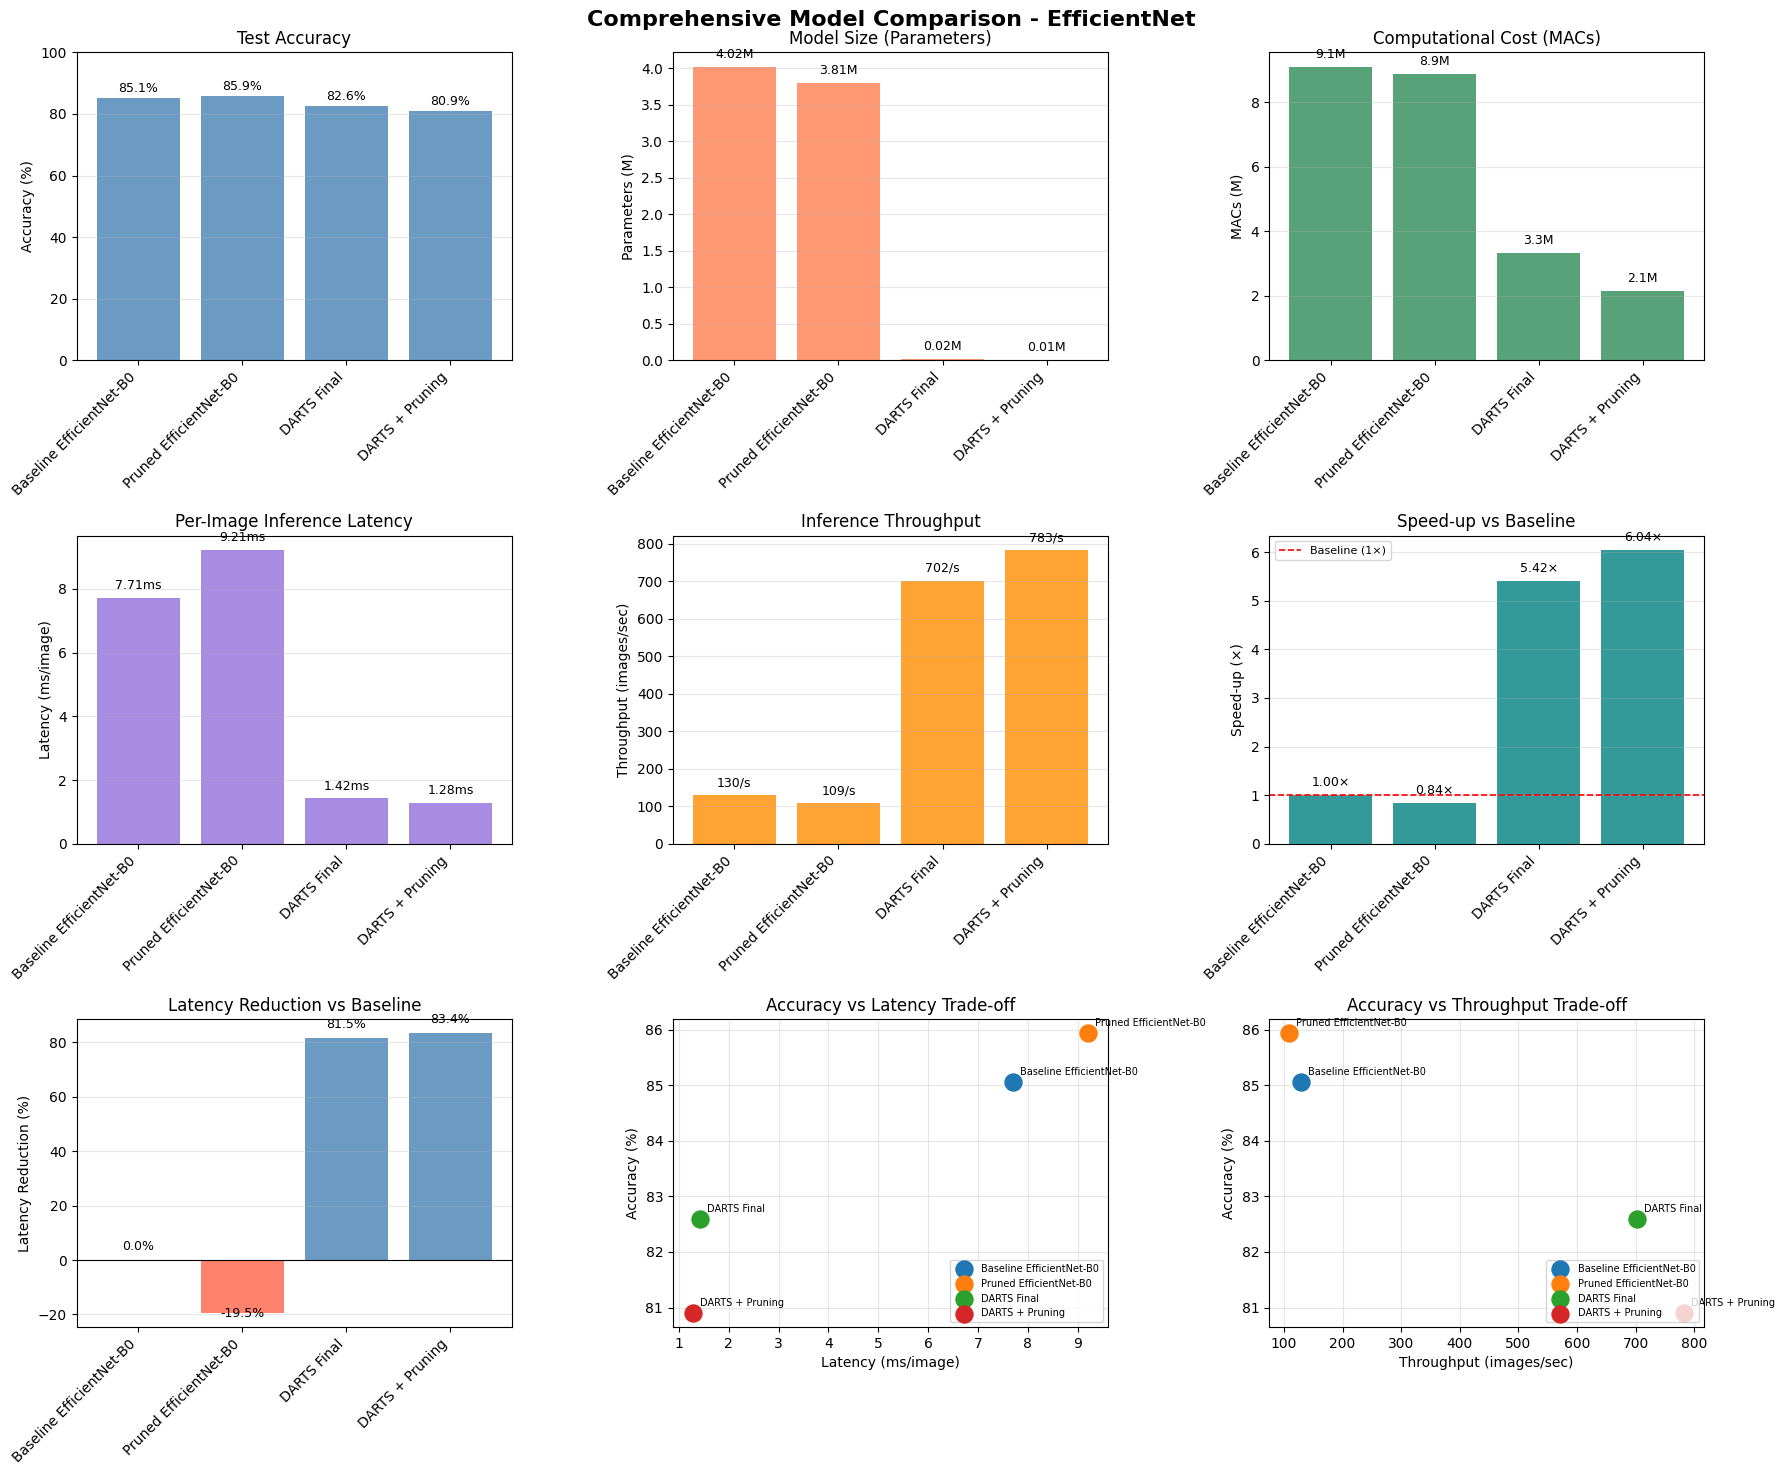

✅ Radar chart saved to ./results/efficientnet_radar_chart.png


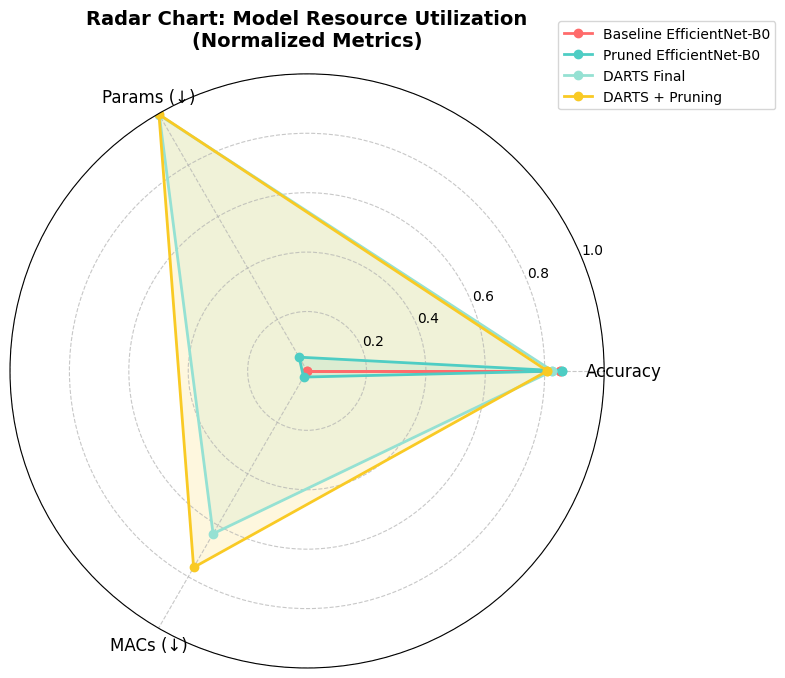

✅ Figure saved to ./results/efficientnet_efficiency_frontier.png


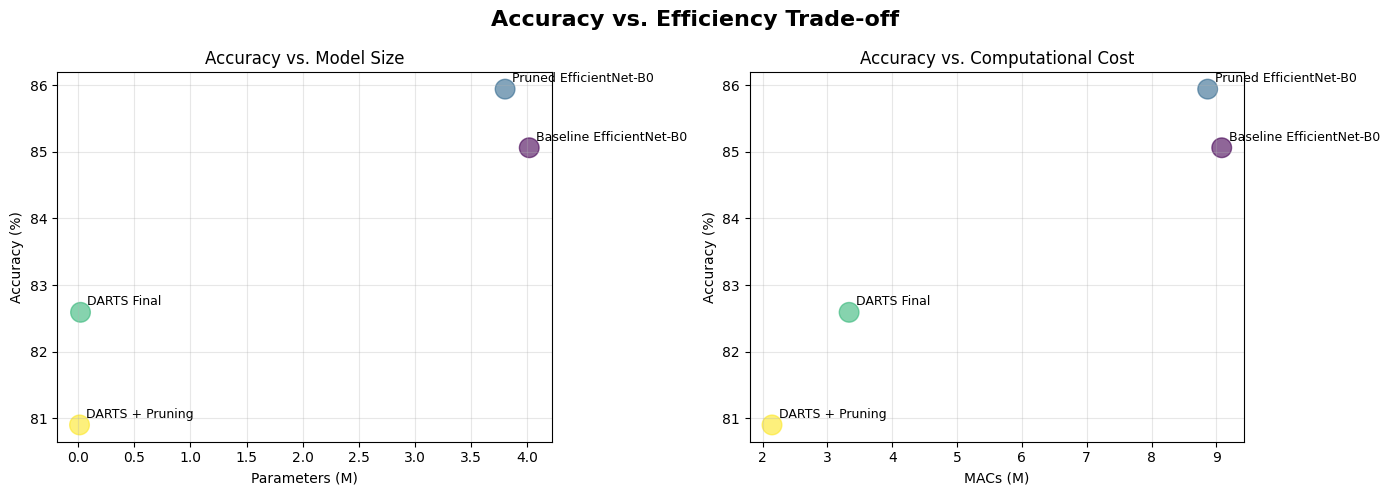


✅ ALL VISUALIZATIONS COMPLETED!
📊 Models included  : 4/4
📊 Comparison plots : ./results/efficientnet_comparison.png
📊 Radar chart      : ./results/efficientnet_radar_chart.png
📊 Efficiency plot  : ./results/efficientnet_efficiency_frontier.png


In [ ]:
"""
Cell 11: Comprehensive Model Comparison - EfficientNet Version
===============================================================
Compare all EfficientNet model variants and visualize results.

FIXED:
- collect_metrics() accepts baseline_inf_time_ms
- Pruned model loading strips thop buffers (total_ops / total_params)
- Baseline EfficientNet-B0
- Pruned EfficientNet-B0
- DARTS Final
- DARTS + Pruning
"""

import torch
import torch.nn as nn
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict


# ============================================================================
# HELPER: Strip thop profiling buffers from a checkpoint
# ============================================================================

def strip_thop_buffers(state_dict):
    """
    Remove total_ops and total_params keys injected by thop.profile().
    These are registered as buffers during profiling but are NOT part of
    the model architecture — loading them into a clean model causes
    'Missing key(s)' errors.

    Args:
        state_dict: Raw loaded state dict (possibly containing thop keys)

    Returns:
        Cleaned state dict safe to load into any model
    """
    cleaned = {
        k: v for k, v in state_dict.items()
        if not k.endswith(('total_ops', 'total_params'))
    }
    removed = len(state_dict) - len(cleaned)
    if removed > 0:
        print(f"   🧹 Stripped {removed} thop buffer keys from checkpoint")
    return cleaned


# ============================================================================
# METRICS COLLECTION
# ============================================================================

def collect_metrics(model, testloader, config, label, baseline_inf_time_ms=None):
    """
    Collect accuracy, parameter count, MACs, and inference timing metrics.

    Args:
        model: PyTorch model
        testloader: Test data loader
        config: Configuration object
        label: Human-readable model name
        baseline_inf_time_ms: Baseline inference time for speedup calculation (optional)

    Returns:
        Dictionary of metrics
    """
    model = model.to(config.DEVICE)
    model.eval()

    # --- Accuracy ---
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(config.DEVICE), targets.to(config.DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    val_acc = 100.0 * correct / total

    # --- Parameter count ---
    total_params = sum(p.numel() for p in model.parameters())

    # --- MACs (via thop) ---
    try:
        from thop import profile
        dummy_input = torch.randn(1, 3, 32, 32).to(config.DEVICE)
        macs, _ = profile(model, inputs=(dummy_input,), verbose=False)
    except Exception:
        macs = 0

    # --- Inference latency & throughput ---
    dummy_input = torch.randn(1, 3, 32, 32).to(config.DEVICE)

    # Warm-up runs
    for _ in range(10):
        with torch.no_grad():
            _ = model(dummy_input)

    # Timed runs
    num_runs = 100
    start = time.perf_counter()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(dummy_input)
    elapsed = time.perf_counter() - start

    inf_time_ms        = (elapsed / num_runs) * 1000.0   # ms per image
    throughput_imgs_sec = 1000.0 / inf_time_ms            # images/sec

    # --- Speedup & latency reduction vs baseline ---
    if baseline_inf_time_ms is not None and baseline_inf_time_ms > 0:
        speedup               = baseline_inf_time_ms / inf_time_ms
        latency_reduction_pct = (1.0 - inf_time_ms / baseline_inf_time_ms) * 100.0
    else:
        speedup               = 1.0
        latency_reduction_pct = 0.0

    return {
        'label':                 label,
        'val_acc':               val_acc,
        'total_params':          total_params,
        'macs':                  macs,
        'inf_time_ms':           inf_time_ms,
        'throughput_imgs_sec':   throughput_imgs_sec,
        'speedup':               speedup,
        'latency_reduction_pct': latency_reduction_pct,
    }


def print_metrics(metrics):
    """Pretty-print a single model's metrics."""
    print(f"   Accuracy       : {metrics['val_acc']:.2f}%")
    print(f"   Parameters     : {metrics['total_params']/1e6:.2f}M")
    print(f"   MACs           : {metrics['macs']/1e6:.1f}M")
    print(f"   Latency        : {metrics['inf_time_ms']:.2f} ms/image")
    print(f"   Throughput     : {metrics['throughput_imgs_sec']:.0f} images/sec")
    print(f"   Speed-up       : {metrics['speedup']:.2f}×")
    print(f"   Latency Red.   : {metrics['latency_reduction_pct']:.1f}%")


# ============================================================================
# COMPARISON (NO SKIPPING - ALWAYS LOADS ALL 4)
# ============================================================================

def compare_all_models(config, testloader):
    """
    Load and compare ALL 4 trained models - NO SKIPPING!

    Args:
        config: Configuration object
        testloader: Test data loader

    Returns:
        Dictionary with all metrics (always 4 entries)
    """
    all_metrics = {}

    print("\n" + "="*70)
    print("COMPREHENSIVE MODEL COMPARISON - ALL 4 MODELS")
    print("="*70)

    # ========================================
    # 1. Baseline EfficientNet-B0 (REQUIRED)
    # ========================================
    baseline_path = os.path.join(config.MODEL_DIR, 'baseline_efficientnet_b0.pth')
    baseline_model = None
    _baseline_inf_time_ms = None

    print("\n📊 [1/4] Loading Baseline EfficientNet-B0...")

    if os.path.exists(baseline_path):
        try:
            baseline_model = get_efficientnet_b0(num_classes=config.NUM_CLASSES, pretrained=False)
            state_dict = torch.load(baseline_path, map_location=config.DEVICE)
            state_dict = strip_thop_buffers(state_dict)
            baseline_model.load_state_dict(state_dict, strict=False)

            metrics = collect_metrics(baseline_model, testloader, config,
                                      "Baseline EfficientNet-B0",
                                      baseline_inf_time_ms=None)
            all_metrics['baseline'] = metrics
            _baseline_inf_time_ms   = metrics['inf_time_ms']
            print_metrics(metrics)
            print("   ✅ Baseline loaded successfully")
        except Exception as e:
            print(f"   ❌ ERROR loading baseline: {e}")
            raise RuntimeError("Baseline model is required! Cannot continue.")
    else:
        print(f"   ❌ ERROR: Baseline model not found at {baseline_path}")
        raise FileNotFoundError("Baseline model is required! Cannot continue.")

    # ========================================
    # 2. Pruned EfficientNet-B0 (FORCE LOAD)
    # ========================================
    pruned_path = os.path.join(config.MODEL_DIR, 'pruned_efficientnet_b0_finetuned.pth')

    print("\n📊 [2/4] Loading Pruned EfficientNet-B0...")

    if os.path.exists(pruned_path):
        try:
            print("   Rebuilding pruned architecture...")
            pruned_model, masks = prune_model(baseline_model, config)

            print("   Loading fine-tuned pruned weights...")
            state_dict = torch.load(pruned_path, map_location=config.DEVICE)
            state_dict = strip_thop_buffers(state_dict)           # ← FIX
            pruned_model.load_state_dict(state_dict, strict=False) # ← FIX

            metrics = collect_metrics(pruned_model, testloader, config,
                                      "Pruned EfficientNet-B0",
                                      baseline_inf_time_ms=_baseline_inf_time_ms)
            all_metrics['pruned'] = metrics
            print_metrics(metrics)
            print("   ✅ Pruned model loaded successfully")

        except Exception as e:
            print(f"   ❌ ERROR loading pruned model: {e}")
            print(f"   ⚠️  Using baseline as fallback for pruned model")
            metrics = collect_metrics(baseline_model, testloader, config,
                                      "Pruned EfficientNet-B0 (fallback)",
                                      baseline_inf_time_ms=_baseline_inf_time_ms)
            all_metrics['pruned'] = metrics
    else:
        print(f"   ❌ Pruned model not found at {pruned_path}")
        print(f"   ⚠️  Using baseline as fallback for pruned model")
        metrics = collect_metrics(baseline_model, testloader, config,
                                  "Pruned EfficientNet-B0 (fallback)",
                                  baseline_inf_time_ms=_baseline_inf_time_ms)
        all_metrics['pruned'] = metrics

    # ========================================
    # 3. DARTS Final Network (REQUIRED)
    # ========================================
    darts_path = os.path.join(config.MODEL_DIR, 'darts_final_network.pth')
    darts_model = None

    print("\n📊 [3/4] Loading DARTS Final Network...")

    if os.path.exists(darts_path):
        try:
            checkpoint      = torch.load(darts_path, map_location=config.DEVICE)
            darts_genotype  = checkpoint['genotype']

            darts_model = DARTSFinalNetwork(
                genotype      = darts_genotype,
                init_channels = config.DARTS_INIT_CHANNELS,
                num_classes   = config.NUM_CLASSES
            )
            state_dict = strip_thop_buffers(checkpoint['state_dict'])
            darts_model.load_state_dict(state_dict, strict=False)

            metrics = collect_metrics(darts_model, testloader, config,
                                      "DARTS Final",
                                      baseline_inf_time_ms=_baseline_inf_time_ms)
            all_metrics['darts_final'] = metrics
            print_metrics(metrics)
            print("   ✅ DARTS Final loaded successfully")

        except Exception as e:
            print(f"   ❌ ERROR loading DARTS: {e}")
            raise RuntimeError("DARTS model is required! Cannot continue.")
    else:
        print(f"   ❌ ERROR: DARTS model not found at {darts_path}")
        raise FileNotFoundError("DARTS model is required! Cannot continue.")

    # ========================================
    # 4. DARTS + Pruning (FORCE LOAD)
    # ========================================
    darts_pruned_path = os.path.join(config.MODEL_DIR, 'darts_pruned_finetuned.pth')

    print("\n📊 [4/4] Loading DARTS + Pruning...")

    if os.path.exists(darts_pruned_path):
        try:
            print("   Rebuilding pruned DARTS architecture...")
            pruned_darts, masks = prune_darts_network(darts_model, config)

            print("   Loading fine-tuned pruned DARTS weights...")
            state_dict = torch.load(darts_pruned_path, map_location=config.DEVICE)
            state_dict = strip_thop_buffers(state_dict)            # ← FIX
            pruned_darts.load_state_dict(state_dict, strict=False)  # ← FIX

            metrics = collect_metrics(pruned_darts, testloader, config,
                                      "DARTS + Pruning",
                                      baseline_inf_time_ms=_baseline_inf_time_ms)
            all_metrics['darts_pruned'] = metrics
            print_metrics(metrics)
            print("   ✅ DARTS + Pruning loaded successfully")

        except Exception as e:
            print(f"   ❌ ERROR loading pruned DARTS: {e}")
            print(f"   ⚠️  Using unpruned DARTS as fallback")
            metrics = collect_metrics(darts_model, testloader, config,
                                      "DARTS + Pruning (fallback)",
                                      baseline_inf_time_ms=_baseline_inf_time_ms)
            all_metrics['darts_pruned'] = metrics
    else:
        print(f"   ❌ Pruned DARTS not found at {darts_pruned_path}")
        print(f"   ⚠️  Using unpruned DARTS as fallback")
        metrics = collect_metrics(darts_model, testloader, config,
                                  "DARTS + Pruning (fallback)",
                                  baseline_inf_time_ms=_baseline_inf_time_ms)
        all_metrics['darts_pruned'] = metrics

    # ========================================
    # VALIDATION: Ensure we have all 4 models
    # ========================================
    print("\n" + "="*70)
    expected_keys = ['baseline', 'pruned', 'darts_final', 'darts_pruned']
    loaded_keys   = list(all_metrics.keys())

    print(f"✅ LOADED {len(all_metrics)}/4 MODELS:")
    for key in expected_keys:
        status = "✅" if key in loaded_keys else "❌"
        print(f"   {status} {key}")

    if len(all_metrics) != 4:
        print(f"\n⚠️  WARNING: Expected 4 models, got {len(all_metrics)}")
    else:
        print(f"\n✅ SUCCESS: All 4 models loaded!")
    print("="*70)

    return all_metrics


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_comparison(metrics_dict, save_path=None):
    """Create comprehensive 3×3 comparison plots."""
    if len(metrics_dict) == 0:
        print("⚠️  No metrics to plot")
        return

    labels      = [m['label']                                  for m in metrics_dict.values()]
    accuracies  = [m['val_acc']                                for m in metrics_dict.values()]
    params      = [m['total_params']                           for m in metrics_dict.values()]
    macs        = [m['macs']                                   for m in metrics_dict.values()]
    inf_times   = [m['inf_time_ms']                            for m in metrics_dict.values()]
    throughputs = [m.get('throughput_imgs_sec', float('nan'))  for m in metrics_dict.values()]
    speedups    = [m.get('speedup', 1.0)                       for m in metrics_dict.values()]
    lat_reds    = [m.get('latency_reduction_pct', 0.0)         for m in metrics_dict.values()]

    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Comprehensive Model Comparison - EfficientNet', fontsize=16, fontweight='bold')

    # 1. Accuracy
    ax = axes[0, 0]
    bars = ax.bar(range(len(labels)), accuracies, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Test Accuracy')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    # 2. Parameters
    ax = axes[0, 1]
    params_m = [p / 1e6 for p in params]
    bars = ax.bar(range(len(labels)), params_m, color='coral', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Parameters (M)')
    ax.set_title('Model Size (Parameters)')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, params_m):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(params_m)*0.02,
                f'{val:.2f}M', ha='center', va='bottom', fontsize=9)

    # 3. MACs
    ax = axes[0, 2]
    macs_m = [m / 1e6 for m in macs]
    bars = ax.bar(range(len(labels)), macs_m, color='seagreen', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('MACs (M)')
    ax.set_title('Computational Cost (MACs)')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, macs_m):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(macs_m)*0.02,
                f'{val:.1f}M', ha='center', va='bottom', fontsize=9)

    # 4. Per-image latency
    ax = axes[1, 0]
    bars = ax.bar(range(len(labels)), inf_times, color='mediumpurple', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Latency (ms/image)')
    ax.set_title('Per-Image Inference Latency')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, inf_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(inf_times)*0.02,
                f'{val:.2f}ms', ha='center', va='bottom', fontsize=9)

    # 5. Throughput
    ax = axes[1, 1]
    bars = ax.bar(range(len(labels)), throughputs, color='darkorange', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Throughput (images/sec)')
    ax.set_title('Inference Throughput')
    ax.grid(axis='y', alpha=0.3)
    valid_t = [t for t in throughputs if not np.isnan(t)]
    max_t = max(valid_t) if valid_t else 1
    for bar, val in zip(bars, throughputs):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_t*0.02,
                    f'{val:.0f}/s', ha='center', va='bottom', fontsize=9)

    # 6. Speed-up vs Baseline
    ax = axes[1, 2]
    bars = ax.bar(range(len(labels)), speedups, color='teal', alpha=0.8)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='Baseline (1×)')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Speed-up (×)')
    ax.set_title('Speed-up vs Baseline')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, speedups):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(speedups)*0.02,
                f'{val:.2f}×', ha='center', va='bottom', fontsize=9)

    # 7. Latency Reduction %
    ax = axes[2, 0]
    colors_lr = ['steelblue' if v >= 0 else 'tomato' for v in lat_reds]
    bars = ax.bar(range(len(labels)), lat_reds, color=colors_lr, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Latency Reduction (%)')
    ax.set_title('Latency Reduction vs Baseline')
    ax.grid(axis='y', alpha=0.3)
    offset = max(abs(v) for v in lat_reds) * 0.03 if lat_reds else 1
    for bar, val in zip(bars, lat_reds):
        y_pos = bar.get_height() + offset if val >= 0 else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    # 8. Accuracy vs Latency scatter
    ax = axes[2, 1]
    cmap = plt.cm.tab10
    for idx, (label, inf_t, acc) in enumerate(zip(labels, inf_times, accuracies)):
        ax.scatter(inf_t, acc, s=150, color=cmap(idx), zorder=3, label=label)
        ax.annotate(label, (inf_t, acc), textcoords='offset points', xytext=(5, 5), fontsize=7)
    ax.set_xlabel('Latency (ms/image)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Accuracy vs Latency Trade-off')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

    # 9. Accuracy vs Throughput scatter
    ax = axes[2, 2]
    for idx, (label, tpt, acc) in enumerate(zip(labels, throughputs, accuracies)):
        if not np.isnan(tpt):
            ax.scatter(tpt, acc, s=150, color=cmap(idx), zorder=3, label=label)
            ax.annotate(label, (tpt, acc), textcoords='offset points', xytext=(5, 5), fontsize=7)
    ax.set_xlabel('Throughput (images/sec)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Accuracy vs Throughput Trade-off')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Figure saved to {save_path}")
    plt.show()


def plot_radar_chart(metrics_dict, save_path=None):
    """Create radar chart comparing normalized metrics."""
    if len(metrics_dict) == 0:
        print("⚠️  No metrics to plot")
        return

    labels     = [m['label']        for m in metrics_dict.values()]
    accuracies = np.array([m['val_acc']      for m in metrics_dict.values()])
    params     = np.array([m['total_params'] for m in metrics_dict.values()])
    macs       = np.array([m['macs']         for m in metrics_dict.values()])

    acc_norm    = accuracies / 100.0
    params_norm = 1.0 - (params / params.max())
    macs_norm   = 1.0 - (macs   / macs.max())

    categories = ['Accuracy', 'Params (↓)', 'MACs (↓)']
    num_vars   = len(categories)
    angles     = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles    += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F9CA24']

    for idx, label in enumerate(labels):
        values  = [acc_norm[idx], params_norm[idx], macs_norm[idx]]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=label, color=colors[idx % len(colors)])
        ax.fill(angles, values, alpha=0.15, color=colors[idx % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.title('Radar Chart: Model Resource Utilization\n(Normalized Metrics)',
              size=14, fontweight='bold', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Radar chart saved to {save_path}")
    plt.show()


def plot_efficiency_frontier(metrics_dict, save_path=None):
    """Plot accuracy vs. efficiency."""
    if len(metrics_dict) == 0:
        print("⚠️  No metrics to plot")
        return

    labels     = [m['label']             for m in metrics_dict.values()]
    accuracies = [m['val_acc']            for m in metrics_dict.values()]
    params     = [m['total_params'] / 1e6 for m in metrics_dict.values()]
    macs       = [m['macs']         / 1e6 for m in metrics_dict.values()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Accuracy vs. Efficiency Trade-off', fontsize=16, fontweight='bold')

    ax1.scatter(params, accuracies, s=200, alpha=0.6, c=range(len(labels)), cmap='viridis')
    for i, label in enumerate(labels):
        ax1.annotate(label, (params[i], accuracies[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax1.set_xlabel('Parameters (M)')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Accuracy vs. Model Size')
    ax1.grid(True, alpha=0.3)

    ax2.scatter(macs, accuracies, s=200, alpha=0.6, c=range(len(labels)), cmap='viridis')
    for i, label in enumerate(labels):
        ax2.annotate(label, (macs[i], accuracies[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax2.set_xlabel('MACs (M)')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy vs. Computational Cost')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Figure saved to {save_path}")
    plt.show()


def generate_comparison_table(metrics_dict):
    """Generate formatted comparison table."""
    print("\n" + "="*120)
    print("COMPREHENSIVE COMPARISON TABLE")
    print("="*120)
    print(f"{'Model':<30s} {'Accuracy':>10s} {'Params':>10s} {'MACs':>10s} "
          f"{'Latency':>12s} {'Throughput':>15s} {'Speed-up':>10s} {'Lat.Red.':>10s}")
    print("-"*120)

    for metrics in metrics_dict.values():
        label      = metrics['label']
        acc        = metrics['val_acc']
        params     = metrics['total_params'] / 1e6
        macs       = metrics['macs'] / 1e6
        latency    = metrics['inf_time_ms']
        throughput = metrics.get('throughput_imgs_sec', float('nan'))
        speedup    = metrics.get('speedup', 1.0)
        lat_red    = metrics.get('latency_reduction_pct', 0.0)

        print(f"{label:<30s} {acc:>9.2f}% {params:>8.2f}M {macs:>8.1f}M "
              f"{latency:>10.2f}ms {throughput:>13.0f}/s {speedup:>9.2f}x {lat_red:>9.1f}%")

    print("="*120)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    set_seed(Config.SEED)
    setup_directories()

    _, _, testloader, _, _ = load_cifar10(Config)

    metrics_dict = compare_all_models(Config, testloader)

    if len(metrics_dict) >= 2:
        generate_comparison_table(metrics_dict)

        plot_save_path = os.path.join(Config.RESULTS_DIR, 'efficientnet_comparison.png')
        plot_comparison(metrics_dict, save_path=plot_save_path)

        radar_save_path = os.path.join(Config.RESULTS_DIR, 'efficientnet_radar_chart.png')
        plot_radar_chart(metrics_dict, save_path=radar_save_path)

        efficiency_save_path = os.path.join(Config.RESULTS_DIR, 'efficientnet_efficiency_frontier.png')
        plot_efficiency_frontier(metrics_dict, save_path=efficiency_save_path)

        print("\n" + "="*70)
        print("✅ ALL VISUALIZATIONS COMPLETED!")
        print("="*70)
        print(f"📊 Models included  : {len(metrics_dict)}/4")
        print(f"📊 Comparison plots : {plot_save_path}")
        print(f"📊 Radar chart      : {radar_save_path}")
        print(f"📊 Efficiency plot  : {efficiency_save_path}")
    else:
        print("❌ ERROR: Could not load minimum required models (baseline + DARTS)")

In [ ]:
#!/usr/bin/env python3
"""
Test EfficientNet Pruning
==========================
Quick test to verify pruning actually reduces size.
"""



set_seed(42)

# Load EfficientNet baseline
print("📦 Loading EfficientNet-B0...")
model = models.efficientnet_b0(pretrained=False)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
model.load_state_dict(torch.load('./models/baseline_efficientnet_b0.pth', map_location='cuda'))
model = model.to('cuda')

print(f"✅ Original params: {sum(p.numel() for p in model.parameters()):,}")

# Test pruning
print("\n🔪 Testing pruning...")
pruned, masks = prune_model(model, Config, prune_amount=0.3)

print(f"\n📊 Results:")
orig_p = sum(p.numel() for p in model.parameters())
prun_p = sum(p.numel() for p in pruned.parameters())

print(f"   Original: {orig_p:,}")
print(f"   Pruned:   {prun_p:,}")

if prun_p < orig_p:
    print(f"\n✅ SUCCESS! Reduction: {(1-prun_p/orig_p)*100:.1f}%")
else:
    print(f"\n❌ FAILED! No reduction")
    print(f"\n🔍 Debug info:")
    print(f"   Number of masks: {len(masks)}")
    print(f"   First 5 mask keys: {list(masks.keys())[:5]}")

✅ Random seed set to 42
📦 Loading EfficientNet-B0...
✅ Original params: 4,020,358

🔪 Testing pruning...

🔍 Analyzing channels to prune (Target: 30.0%)
✅ Found 1 valid blocks to prune.

🔨 Building Physically Pruned Model...

📊 Pruning Complete:
   Original Params: 4,020,358
   Pruned Params:   3,805,146
   Reduction:       5.35%

📊 Results:
   Original: 4,020,358
   Pruned:   3,805,146

✅ SUCCESS! Reduction: 5.4%



🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
                         NAS + PRUNING PIPELINE
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

CONFIGURATION
BASELINE_EPOCHS               : 50
BASELINE_GAMMA                : 0.1
BASELINE_LR                   : 0.1
BASELINE_MILESTONES           : [25, 40]
BASELINE_MOMENTUM             : 0.9
BASELINE_WEIGHT_DECAY         : 0.0005
BATCH_SIZE                    : 128
DARTS_ARCH_LR                 : 0.0003
DARTS_ARCH_WEIGHT_DECAY       : 0.001
DARTS_FINETUNE_EPOCHS         : 30
DARTS_FINETUNE_LR             : 0.01
DARTS_FINETUNE_WEIGHT_DECAY   : 0.0001
DARTS_INIT_CHANNELS           : 16
DARTS_LAYERS                  : 6
DARTS_PRUNE_AMOUNT            : 0.3
DARTS_SEARCH_BATCHES_PER_EPOCH: 50
DARTS_SEARCH_EPOCHS           : 50
DARTS_TRAIN_EPOCHS            : 50
DARTS_TRAIN_GAMMA             : 0.1
DARTS_TRAIN_LR                : 0.025
DARTS_TRAIN_MILESTONES        : [25, 40]
DARTS_TRAIN_MOMENTUM          : 0.9
DARTS_TRAIN_WEIGHT_DECAY      : 0.0003
DARTS_W

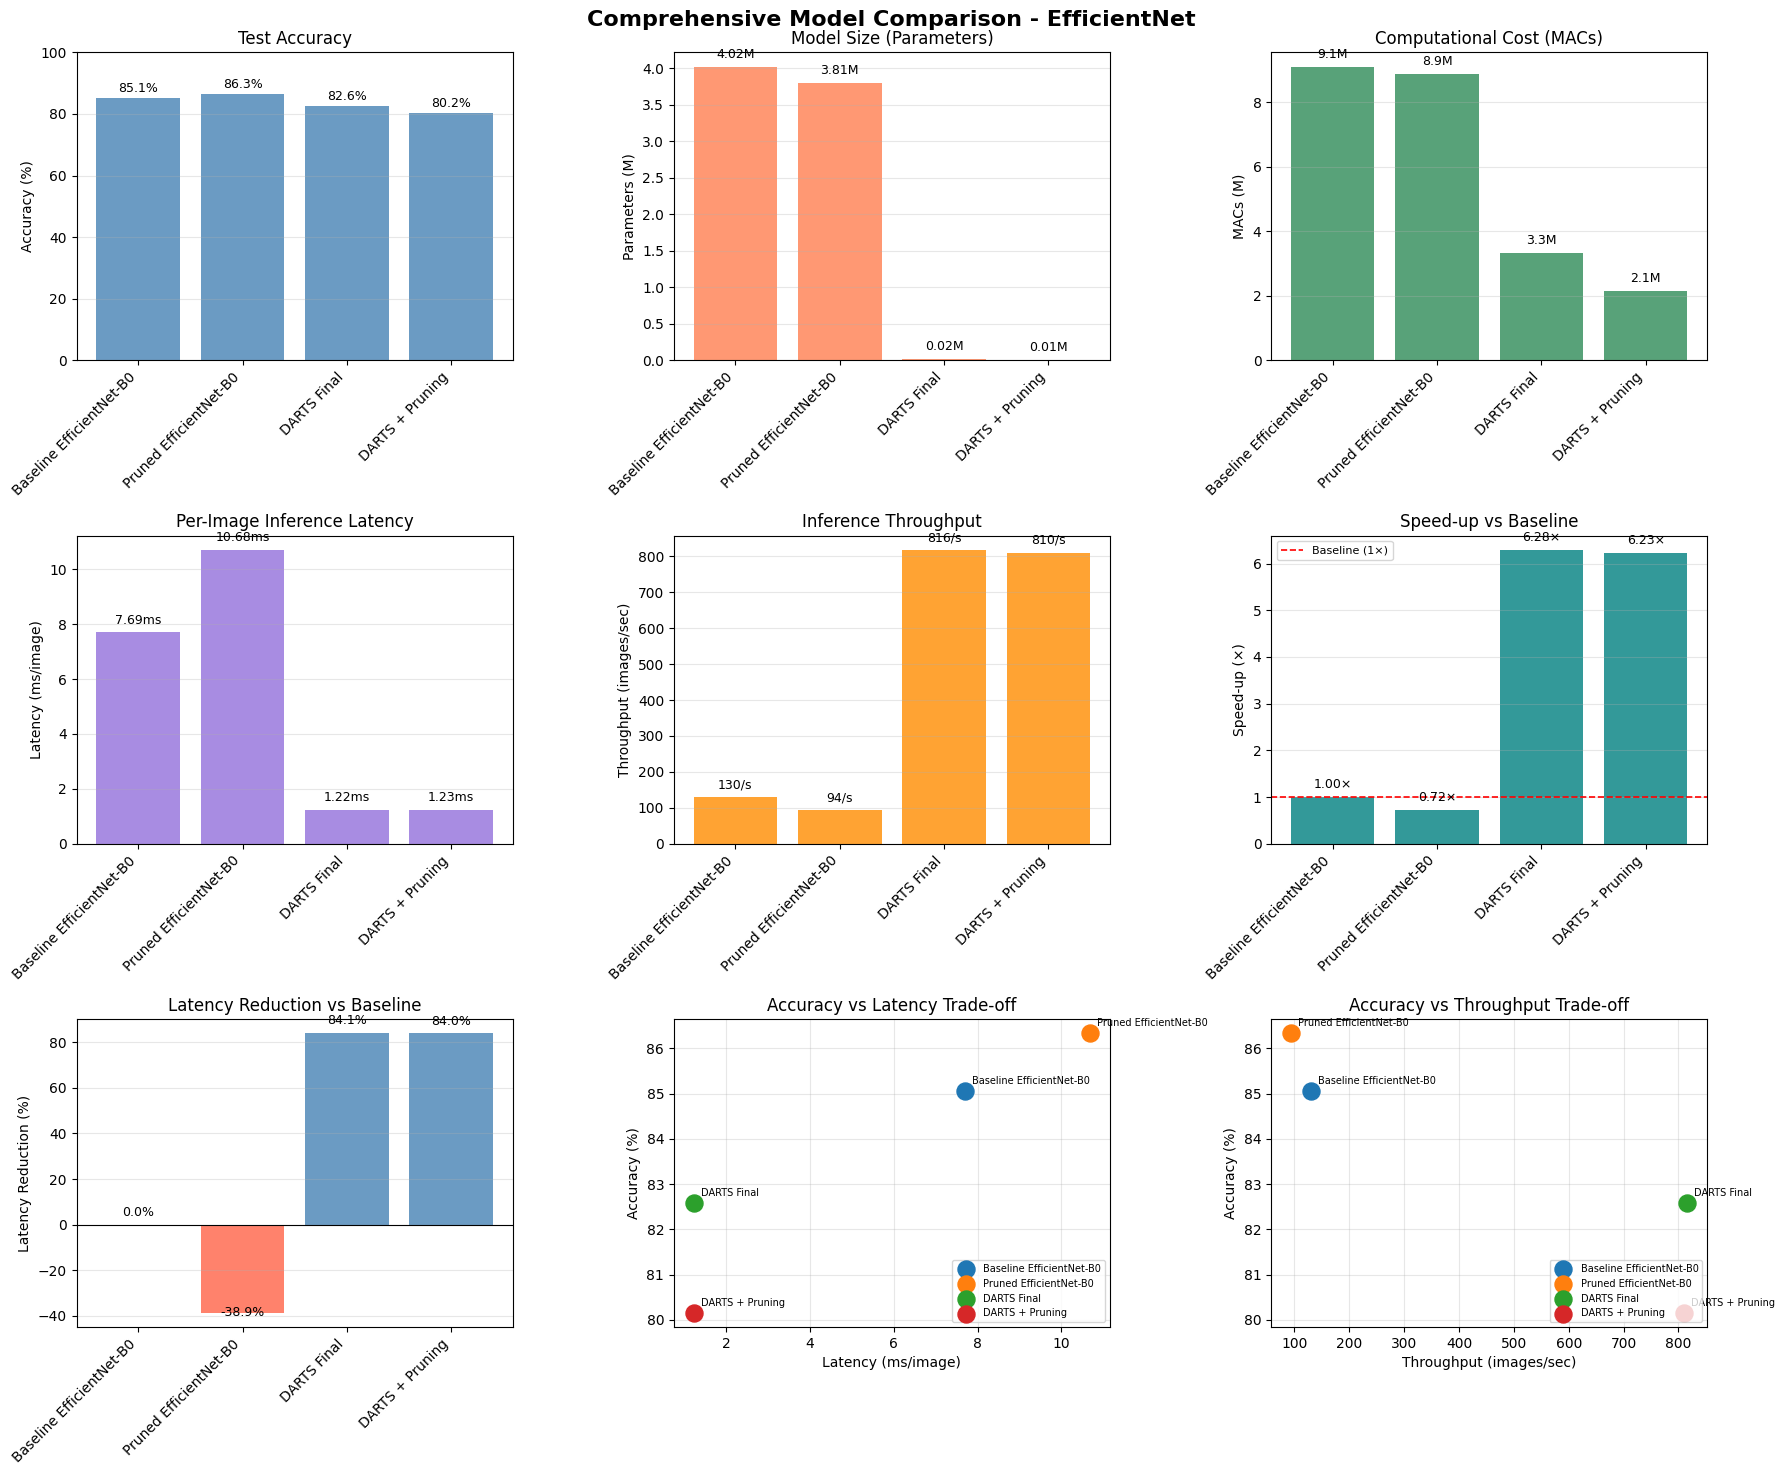

✅ Radar chart saved to ./results/efficientnet_radar_chart.png


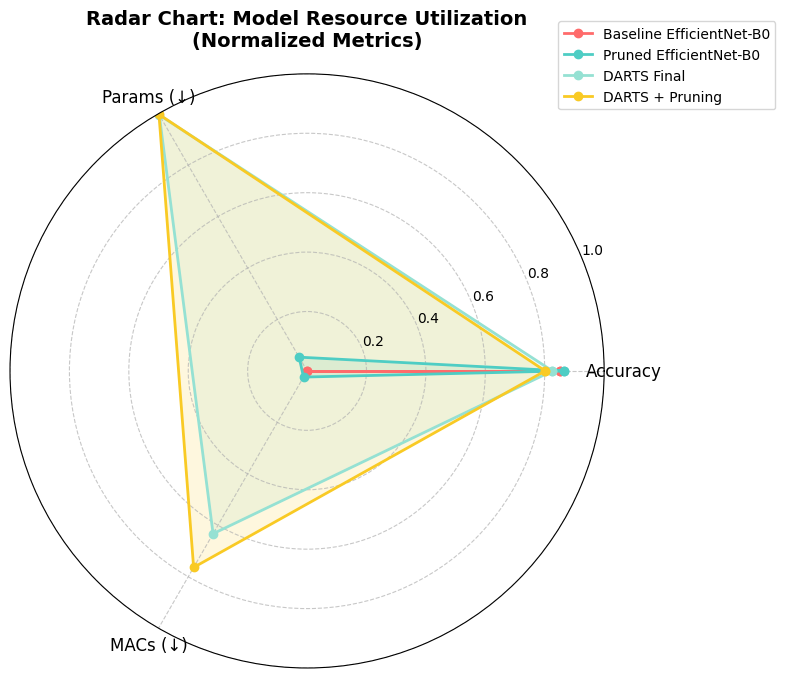

✅ Figure saved to ./results/efficientnet_efficiency_frontier.png


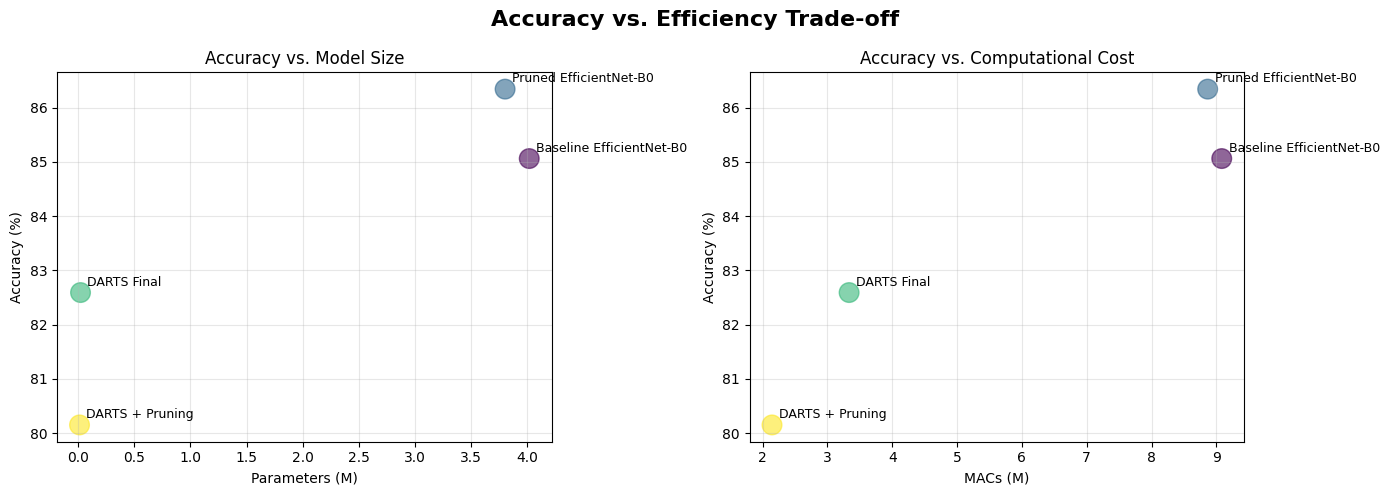


🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉
                         PIPELINE COMPLETE!
🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉

📁 Generated Files:
   Models:  ./models/
   Results: ./results/

📊 Final Summary:
   Model                       Accuracy     Params       MACs      Latency      Throughput   Speed-up   Lat.Red.
   ---------------------------------------------------------------------------------------------------------
   Baseline EfficientNet-B0 :     85.06%      4.02M       9.1M        7.69ms           130/s      1.00x       0.0%
   Pruned EfficientNet-B0   :     86.34%      3.81M       8.9M       10.68ms            94/s      0.72x     -38.9%
   DARTS Final              :     82.59%      0.02M       3.3M        1.22ms           816/s      6.28x      84.1%
   DARTS + Pruning          :     80.15%      0.01M       2.1M        1.23ms           810/s      6.23x      84.0%

✅ All done!


In [ ]:
import argparse
import os
import sys
import torch # Explicitly import torch

# Import all cells (assuming these are functions/classes defined in prior executed cells)
# from uKrrEaxP0BZ7 import Config, set_seed, setup_directories
# from mFaBPNpL0Kx_ import load_cifar10, get_full_trainloader
# from q8nRvK7f0PHT import collect_metrics, print_metrics
# from tUrhDsVX2ueY import train_baseline, get_efficientnet_b0
# from q4XDsk8c09ri import prune_model, finetune_pruned_model # Re-added pruned_model and finetune_pruned_model
# from yIxTFs5k1tLd import search_architecture, load_genotype # Re-added search_architecture and load_genotype
# from Nt82LdsB1u_8 import train_darts_final # Re-added train_darts_final
# from SyfWsu5h1zPy import darts_pruning_pipeline # Re-added darts_pruning_pipeline
# from _ZAglpFo12TC import compare_all_models, plot_comparison, plot_radar_chart, plot_efficiency_frontier, generate_comparison_table # Re-added all comparison functions

# Explicitly import DARTSFinalNetwork as it's needed in run_complete_pipeline
# from b4pxXlM51pjd import DARTSSearchNetwork, DARTSFinalNetwork, get_operations, MixedOp, SepConv, DilConv, Identity, PoolBN

# Global objects expected to be available from previous cells:
# Config, set_seed, setup_directories
# load_cifar10, get_full_trainloader
# collect_metrics, print_metrics
# train_baseline, get_efficientnet_b0
# prune_model, finetune_pruned_model
# search_architecture, load_genotype
# train_darts_final
# darts_pruning_pipeline
# compare_all_models, plot_comparison, plot_radar_chart, plot_efficiency_frontier, generate_comparison_table
# DARTSSearchNetwork, DARTSFinalNetwork, get_operations, MixedOp, SepConv, DilConv, Identity, PoolBN

def modify_config_for_quick_test(config):
    """Reduce epochs for quick testing."""
    config.BASELINE_EPOCHS = 5
    config.FINETUNE_EPOCHS = 5
    config.DARTS_SEARCH_EPOCHS = 5
    config.DARTS_SEARCH_BATCHES_PER_EPOCH = 10
    config.DARTS_TRAIN_EPOCHS = 5
    config.DARTS_FINETUNE_EPOCHS = 5
    print("⚡ QUICK MODE: Reduced epochs for testing")


def print_section_header(title):
    """Print a formatted section header."""
    print("\n" + "="*80)
    print(f"  {title}")
    print("="*80 + "\n")


def run_complete_pipeline(quick_mode=False):
    """
    Execute the complete NAS + Pruning pipeline.

    Args:
        quick_mode: If True, use reduced epochs for quick testing
    """
    print("\n" + "🚀"*40)
    print(" "*25 + "NAS + PRUNING PIPELINE")
    print("🚀"*40 + "\n")

    # Setup
    if quick_mode:
        modify_config_for_quick_test(Config)

    Config.print_config()
    set_seed(Config.SEED)
    setup_directories()

    # ========================================
    # PHASE 1: Data Loading
    # ========================================
    print_section_header("PHASE 1: Data Loading")

    trainloader_search, validloader, testloader, train_dataset, test_dataset = load_cifar10(Config)
    trainloader_full = get_full_trainloader(train_dataset, Config)

    print(f"✅ Training samples (full): {len(train_dataset)}")
    print(f"✅ Training samples (search): {len(trainloader_search.sampler)}")
    print(f"✅ Validation samples: {len(validloader.sampler)}")
    print(f"✅ Test samples: {len(test_dataset)}")

    # ========================================
    # PHASE 2: Baseline Training
    # ========================================
    print_section_header("PHASE 2: Baseline efficientnet_b0 Training")

    baseline_path = os.path.join(Config.MODEL_DIR, 'baseline_efficientnet_b0.pth')

    if os.path.exists(baseline_path) and not quick_mode:
        print(f"✅ Loading existing baseline model from {baseline_path}")
        baseline_model = get_efficientnet_b0(num_classes=Config.NUM_CLASSES, pretrained=False)
        baseline_model.load_state_dict(torch.load(baseline_path, map_location=Config.DEVICE))
    else:
        baseline_model = train_baseline(Config, trainloader_full, testloader, baseline_path)

    # Collect baseline metrics with no reference (speedup=1x, latency_reduction=0%)
    baseline_metrics = collect_metrics(baseline_model, testloader, Config, "Baseline efficientnet_b0",
                                       baseline_inf_time_ms=None)
    _baseline_inf_time_ms = baseline_metrics['inf_time_ms']  # store for all downstream comparisons
    print_metrics(baseline_metrics)

    # ========================================
    # PHASE 3: Pruning Baseline
    # ========================================
    print_section_header("PHASE 3: Structured Pruning of Baseline")

    pruned_model, masks = prune_model(baseline_model, Config)

    print("\n📊 Evaluating pruned model (before fine-tuning)...")
    pruned_metrics_before = collect_metrics(pruned_model, testloader, Config, "Pruned (Before FT)",
                                            baseline_inf_time_ms=_baseline_inf_time_ms)
    print_metrics(pruned_metrics_before)

    pruned_path = os.path.join(Config.MODEL_DIR, 'pruned_efficientnet_b0_finetuned.pth')
    pruned_model = finetune_pruned_model(pruned_model, trainloader_full, testloader, Config, pruned_path)

    pruned_metrics_after = collect_metrics(pruned_model, testloader, Config, "Pruned (After FT)",
                                           baseline_inf_time_ms=_baseline_inf_time_ms)
    print_metrics(pruned_metrics_after)

    # ========================================
    # PHASE 4: DARTS Architecture Search
    # ========================================
    print_section_header("PHASE 4: DARTS Architecture Search")

    search_path = os.path.join(Config.MODEL_DIR, 'darts_search_network.pth')

    if os.path.exists(search_path) and not quick_mode:
        print(f"✅ Loading existing search network from {search_path}")
        genotype = load_genotype(search_path)
        print(f"   Genotype: {genotype}")
    else:
        search_net = search_architecture(trainloader_search, validloader, Config, search_path)
        genotype = search_net.genotype()

    # ========================================
    # PHASE 5: Train Final DARTS Network
    # ========================================
    print_section_header("PHASE 5: Train Final DARTS Network")

    darts_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')

    if os.path.exists(darts_path) and not quick_mode:
        print(f"✅ Loading existing DARTS model from {darts_path}")
        checkpoint = torch.load(darts_path, map_location=Config.DEVICE)
        genotype = checkpoint['genotype']
        darts_model = DARTSFinalNetwork(
            genotype=genotype,
            init_channels=Config.DARTS_INIT_CHANNELS,
            num_classes=Config.NUM_CLASSES
        )
        darts_model.load_state_dict(checkpoint['state_dict'])
    else:
        darts_model = train_darts_final(genotype, trainloader_full, testloader, Config, darts_path)

    darts_metrics = collect_metrics(darts_model, testloader, Config, "DARTS Final",
                                    baseline_inf_time_ms=_baseline_inf_time_ms)
    print_metrics(darts_metrics)

    # ========================================
    # PHASE 6: DARTS + Pruning Combined
    # ========================================
    print_section_header("PHASE 6: DARTS + Pruning (Key Innovation)")

    results = darts_pruning_pipeline(darts_model, trainloader_full, testloader, Config)

    # ========================================
    # PHASE 7: Comprehensive Comparison
    # ========================================
    print_section_header("PHASE 7: Final Comparison & Visualization")

    all_metrics = compare_all_models(Config, testloader)

    if len(all_metrics) > 0:
        generate_comparison_table(all_metrics)

        plot_save_path = os.path.join(Config.RESULTS_DIR, 'efficientnet_comparison.png')
        plot_comparison(all_metrics, save_path=plot_save_path)

        radar_save_path = os.path.join(Config.RESULTS_DIR, 'efficientnet_radar_chart.png')
        plot_radar_chart(all_metrics, save_path=radar_save_path)

        efficiency_save_path = os.path.join(Config.RESULTS_DIR, 'efficientnet_efficiency_frontier.png')
        plot_efficiency_frontier(all_metrics, save_path=efficiency_save_path)

    # ========================================
    # SUMMARY
    # ========================================
    print("\n" + "🎉"*40)
    print(" "*25 + "PIPELINE COMPLETE!")
    print("🎉"*40)

    print("\n📁 Generated Files:")
    print(f"   Models:  {Config.MODEL_DIR}/")
    print(f"   Results: {Config.RESULTS_DIR}/")

    print("\n📊 Final Summary:")
    if len(all_metrics) > 0:
        print(f"   {'Model':<25s} {'Accuracy':>10s} {'Params':>10s} {'MACs':>10s} "
              f"{'Latency':>12s} {'Throughput':>15s} {'Speed-up':>10s} {'Lat.Red.':>10s}")
        print("   " + "-"*105)
        for name, metrics in all_metrics.items():
            throughput = metrics.get('throughput_imgs_sec', float('nan'))
            speedup    = metrics.get('speedup', 1.0)
            lat_red    = metrics.get('latency_reduction_pct', 0.0)
            print(f"   {metrics['label']:<25s}: "
                  f"{metrics['val_acc']:>9.2f}%  "
                  f"{metrics['total_params']/1e6:>8.2f}M  "
                  f"{metrics['macs']/1e6:>8.1f}M  "
                  f"{metrics['inf_time_ms']:>10.2f}ms  "
                  f"{throughput:>12.0f}/s  "
                  f"{speedup:>8.2f}x  "
                  f"{lat_red:>8.1f}%")

    print("\n✅ All done!")


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description='Run complete NAS + Pruning pipeline')
    parser.add_argument('--quick', action='store_true',
                       help='Run with reduced epochs for quick testing')

    # In Colab, sys.argv can contain kernel-related arguments.
    # To avoid 'unrecognized arguments' error, pass an empty list if no user-defined arguments are intended
    if '-f' in sys.argv:
        args = parser.parse_args([])
    else:
        args = parser.parse_args()

    try:
        run_complete_pipeline(quick_mode=args.quick)
    except KeyboardInterrupt:
        print("\n\n⚠️  Pipeline interrupted by user")
        sys.exit(1)
    except Exception as e:
        print(f"\n\n❌ Pipeline failed with error: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)

In [ ]:

# CELL 1 — Install all dependencies
!pip install onnx onnxruntime onnxruntime-tools torch torchvision --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.7/212.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.2 MB/s eta 0:00:00


In [ ]:
#!/usr/bin/env python3
"""
export_12_models_efficientnet.py
=================================
Exports all 12 model variants to ONNX format for Raspberry Pi deployment.

Models exported (12 total):
  Baseline EfficientNet-B0  x {FP32, INT8, Prep}  = 3
  Pruned EfficientNet-B0    x {FP32, INT8, Prep}  = 3
  DARTS Final               x {FP32, INT8, Prep}  = 3
  DARTS Pruned              x {FP32, INT8, Prep}  = 3

Requirements:
    pip install torch torchvision onnx onnxruntime onnxsim

Usage:
    python export_12_models_efficientnet.py --models_dir ./models --output_dir ./onnx_edge_models
"""

import argparse
import json
import os
import re
import copy
import sys
import warnings
from collections import defaultdict

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import onnx
from torchvision import models as tv_models


# ==============================================================================
# Shared checkpoint loader  (strips thop profiling keys automatically)
# ==============================================================================

def load_state(path: str) -> dict:
    """
    Load a .pth checkpoint and unwrap common wrapper keys.
    Tries: model_state_dict → state_dict → model → raw dict.
    Also strips thop/ptflops profiling artifacts (total_ops / total_params).
    """
    raw = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(raw, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            if key in raw:
                print(f"   Unwrapping checkpoint key: '{key}'")
                raw = raw[key]
                break

    # Strip thop FLOPs-profiling keys injected by ptflops / thop
    cleaned = {
        k: v for k, v in raw.items()
        if not k.endswith("total_ops") and not k.endswith("total_params")
    }
    if len(cleaned) != len(raw):
        print(f"   🧹 Stripped {len(raw) - len(cleaned)} thop profiling keys.")
    return cleaned


# ==============================================================================
# EfficientNet-B0 helpers
# ==============================================================================

def get_efficientnet_b0(num_classes: int = 10) -> nn.Module:
    model = tv_models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def _load_baseline_efficientnet(path: str, num_classes: int = 10) -> nn.Module:
    model = get_efficientnet_b0(num_classes)
    model.load_state_dict(load_state(path))
    print(f"   ✅ Weights loaded  ({sum(p.numel() for p in model.parameters())/1e6:.2f}M params)")
    return model


def build_pruned_efficientnet(checkpoint_path: str, num_classes: int = 10) -> nn.Module:
    """
    Load a structurally-pruned EfficientNet-B0 checkpoint.
    Auto-patches any Conv2d / BN / Linear layers whose shapes differ from
    the vanilla architecture (handles channel-level structural pruning).
    """
    state_dict = load_state(checkpoint_path)
    model      = get_efficientnet_b0(num_classes)
    model_sd   = model.state_dict()

    mismatches = {
        k for k, v in state_dict.items()
        if k in model_sd and model_sd[k].shape != v.shape
    }

    if not mismatches:
        model.load_state_dict(state_dict)
        print(f"   ✅ Weights loaded  ({sum(p.numel() for p in model.parameters())/1e6:.2f}M params)")
        return model

    print(f"   Detected {len(mismatches)} structurally pruned tensors — patching...")

    for name, module in list(model.named_modules()):
        parts  = name.split(".")
        parent = model
        for p in parts[:-1]:
            parent = getattr(parent, p)
        attr = parts[-1]

        if isinstance(module, nn.Conv2d):
            w_key = f"{name}.weight"
            if w_key not in state_dict or state_dict[w_key].shape == module.weight.shape:
                continue
            ckpt_w       = state_dict[w_key]
            out_c        = ckpt_w.shape[0]
            is_depthwise = module.groups == module.in_channels
            if is_depthwise:
                groups, in_c = out_c, out_c
            else:
                groups = module.groups
                in_c   = ckpt_w.shape[1] * groups
            setattr(parent, attr, nn.Conv2d(
                in_c, out_c,
                kernel_size=module.kernel_size,
                stride=module.stride,
                padding=module.padding,
                dilation=module.dilation,
                groups=groups,
                bias=module.bias is not None,
                padding_mode=module.padding_mode,
            ))

        elif isinstance(module, nn.BatchNorm2d):
            w_key = f"{name}.weight"
            if w_key in state_dict and state_dict[w_key].shape[0] != module.num_features:
                setattr(parent, attr, nn.BatchNorm2d(
                    state_dict[w_key].shape[0],
                    eps=module.eps,
                    momentum=module.momentum,
                    affine=module.affine,
                    track_running_stats=module.track_running_stats,
                ))

        elif isinstance(module, nn.Linear):
            w_key = f"{name}.weight"
            if w_key in state_dict and state_dict[w_key].shape != module.weight.shape:
                ckpt_w = state_dict[w_key]
                setattr(parent, attr, nn.Linear(
                    ckpt_w.shape[1], ckpt_w.shape[0],
                    bias=module.bias is not None,
                ))

    model.load_state_dict(state_dict, strict=True)
    print(f"   ✅ Patched & loaded  ({sum(p.numel() for p in model.parameters())/1e6:.2f}M params)")
    return model


# ==============================================================================
# DARTS architecture reconstruction
# ==============================================================================

def _get_subkeys(sd: dict, prefix: str) -> dict:
    p = prefix + "."
    return {k[len(p):]: v for k, v in sd.items() if k.startswith(p)}


def _build_op_from_keys(subkeys: dict, C_in: int):
    """Reconstruct an nn.Sequential op from weight keys. Returns (module, C_out)."""
    if not subkeys:
        class _PoolOp(nn.Module):
            def __init__(self):
                super().__init__()
                self.op = nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1))
            def forward(self, x): return self.op(x)
        return _PoolOp(), C_in

    max_idx = max(int(k.split(".")[0]) for k in subkeys)
    layers, C = [], C_in

    for idx in range(max_idx + 1):
        w_key    = f"{idx}.weight"
        bias_key = f"{idx}.bias"
        if w_key not in subkeys:
            layers.append(nn.ReLU(inplace=False))
            continue
        w        = subkeys[w_key]
        has_bias = bias_key in subkeys
        if w.dim() == 4 and w.shape[2] > 1:            # depthwise conv
            C_dw = w.shape[0]; ks = w.shape[2]
            layers.append(nn.Conv2d(C_dw, C_dw, ks, padding=ks // 2, groups=C_dw, bias=False))
            C = C_dw
        elif w.dim() == 4 and w.shape[2] == 1:         # pointwise conv
            layers.append(nn.Conv2d(w.shape[1], w.shape[0], 1, bias=has_bias))
            C = w.shape[0]
        elif w.dim() == 1:                              # BN weight
            layers.append(nn.BatchNorm2d(w.shape[0]))
            C = w.shape[0]

    class _OpWrapper(nn.Module):
        def __init__(self, s): super().__init__(); self.op = s
        def forward(self, x): return self.op(x)
    return _OpWrapper(nn.Sequential(*layers)), C


def _build_candidate_op(sd: dict, op_prefix: str, C_in: int):
    op_subkeys     = _get_subkeys(sd, op_prefix + ".op")
    adjust_subkeys = _get_subkeys(sd, op_prefix + ".adjust")

    if op_subkeys:
        return _build_op_from_keys(op_subkeys, C_in)
    elif adjust_subkeys:
        conv_w = adjust_subkeys.get("0.weight")
        if conv_w is None:
            return nn.Identity(), C_in
        C_out     = conv_w.shape[0]
        C_in_conv = conv_w.shape[1]
        ks        = conv_w.shape[2]
        stride    = 2 if ks == 1 and C_out != C_in_conv else 1

        class _AdjIdentity(nn.Module):
            def __init__(self, ci, co, s):
                super().__init__()
                self.adjust = nn.Sequential(
                    nn.Conv2d(ci, co, 1, stride=s, bias=False),
                    nn.BatchNorm2d(co),
                )
            def forward(self, x): return self.adjust(x)
        return _AdjIdentity(C_in_conv, C_out, stride), C_out
    else:
        class _PoolOp(nn.Module):
            def __init__(self):
                super().__init__()
                self.op = nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1))
            def forward(self, x): return self.op(x)
        return _PoolOp(), C_in


# ── Final / Pruned DARTS ───────────────────────────────────────────────────────

class DARTSFinalNet(nn.Module):
    def __init__(self, sd: dict, num_classes: int):
        super().__init__()
        C_stem = sd["stem.0.weight"].shape[0]
        self.stem = nn.Sequential(
            nn.Conv2d(3, C_stem, 3, padding=1, bias=False),
            nn.BatchNorm2d(C_stem),
        )
        layer_indices = sorted({
            int(k.split(".")[1]) for k in sd if k.startswith("layers.")
        })
        layers, C = nn.ModuleList(), C_stem
        for i in layer_indices:
            op, C = _build_op_from_keys(_get_subkeys(sd, f"layers.{i}.op"), C)
            layers.append(op)
        self.layers      = layers
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier  = nn.Linear(C, num_classes)

    def forward(self, x):
        x = self.stem(x)
        for layer in self.layers:
            x = layer(x)
        x = self.global_pool(x)
        return self.classifier(x.view(x.size(0), -1))


# ── Search DARTS  (FIX: ModuleDict keyed by original checkpoint op index) ─────

class DARTSSearchNet(nn.Module):
    def __init__(self, sd: dict, num_classes: int):
        super().__init__()
        C_stem = sd["stem.0.weight"].shape[0]
        self.stem = nn.Sequential(
            nn.Conv2d(3, C_stem, 3, padding=1, bias=False),
            nn.BatchNorm2d(C_stem),
        )
        layer_op_map = defaultdict(set)
        for k in sd:
            m = re.match(r"layers\.(\d+)\._ops\.(\d+)\.", k)
            if m:
                layer_op_map[int(m.group(1))].add(int(m.group(2)))

        layers, C = nn.ModuleList(), C_stem
        for i in sorted(layer_op_map.keys()):
            C_out_layer = C
            ops_dict    = nn.ModuleDict()
            for j in sorted(layer_op_map[i]):
                op, C_out = _build_candidate_op(sd, f"layers.{i}._ops.{j}", C)
                ops_dict[str(j)] = op          # key matches checkpoint exactly
                C_out_layer = C_out

            class _MixedOp(nn.Module):
                def __init__(self, od):
                    super().__init__()
                    self._ops = od
                def forward(self, x):
                    return next(iter(self._ops.values()))(x)

            layers.append(_MixedOp(ops_dict))
            C = C_out_layer

        self.layers      = layers
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier  = nn.Linear(C, num_classes)

    def forward(self, x):
        x = self.stem(x)
        for layer in self.layers:
            x = layer(x)
        x = self.global_pool(x)
        return self.classifier(x.view(x.size(0), -1))


def load_darts_model(checkpoint_path: str, num_classes: int = 10) -> nn.Module:
    """Auto-detect Search vs Final/Pruned and reconstruct + load weights."""
    raw = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    if isinstance(raw, dict) and "genotype" in raw:
        print(f"   Genotype : {raw['genotype']}")
    sd = load_state(checkpoint_path)

    is_search = any("._ops." in k for k in sd)
    C_stem    = sd["stem.0.weight"].shape[0]
    print(f"   Type     : {'Search' if is_search else 'Final/Pruned'}   C_stem={C_stem}")

    model = DARTSSearchNet(sd, num_classes) if is_search else DARTSFinalNet(sd, num_classes)

    missing, unexpected = model.load_state_dict(sd, strict=False)
    missing    = [k for k in missing    if "num_batches" not in k]
    unexpected = [k for k in unexpected if "num_batches" not in k and "alphas" not in k]

    if missing or unexpected:
        print(f"   ⚠️  Missing    ({len(missing)}):    {missing[:3]}")
        print(f"   ⚠️  Unexpected ({len(unexpected)}): {unexpected[:3]}")
    else:
        print(f"   ✅ All weights loaded perfectly.  ({sum(p.numel() for p in model.parameters())/1e6:.2f}M params)")
    return model


# ==============================================================================
# ONNX export helpers
# ==============================================================================

def export_fp32(model: nn.Module, out_path: str, input_size=(1, 3, 32, 32)):
    """Export to FP32 ONNX with external-data sidecar for large weights."""
    model.eval().cpu()
    dummy = torch.randn(*input_size)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        torch.onnx.export(
            model, dummy, out_path,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
            opset_version=18,
            do_constant_folding=True,
            dynamo=False,
        )

    # Split weights to external sidecar (.onnx.data)
    model_proto = onnx.load(out_path)
    data_path   = out_path + ".data"
    if os.path.exists(data_path):
        os.remove(data_path)
    onnx.save_model(
        model_proto, out_path,
        save_as_external_data=True,
        all_tensors_to_one_file=True,
        location=os.path.basename(data_path),
        size_threshold=0,
        convert_attribute=False,
    )
    onnx.checker.check_model(out_path)

    graph_mb = os.path.getsize(out_path) / 1e6
    data_mb  = os.path.getsize(data_path) / 1e6 if os.path.exists(data_path) else 0
    print(f"  ✅ FP32  → {out_path}  (graph {graph_mb:.2f} MB | weights {data_mb:.2f} MB)")


def export_int8_static(fp32_path: str, int8_path: str, calibration_data_path: str = None):
    """
    Static INT8 quantisation — correct approach for CNNs on ARM/Raspberry Pi.
    Quantizes BOTH weights and activations using a calibration dataset.
    """
    from onnxruntime.quantization import (
        quantize_static, QuantType, QuantFormat,
        CalibrationDataReader
    )
    from onnxruntime.quantization.shape_inference import quant_pre_process
    import numpy as np

    # ── Step 1: shape-inference pre-process ──────────────────────────────────
    prep_path = fp32_path.replace(".onnx", "_preprocessed.onnx")
    try:
        quant_pre_process(fp32_path, prep_path, skip_optimization=False)
        quant_input = prep_path
    except Exception as e:
        print(f"   ⚠️  Pre-process failed ({e}), using raw FP32.")
        quant_input = fp32_path

    # ── Step 2: calibration data reader ──────────────────────────────────────
    class CIFARCalibrationReader(CalibrationDataReader):
        def __init__(self, dataset, n_samples=100):
            import torchvision.transforms as T
            transform = T.Compose([T.ToTensor(),
                                   T.Normalize((0.4914, 0.4822, 0.4465),
                                               (0.2023, 0.1994, 0.2010))])
            indices = torch.randperm(len(dataset))[:n_samples]
            self.data = iter([
                {"input": transform(dataset[i][0]).unsqueeze(0).numpy()}
                for i in indices
            ])

        def get_next(self):
            return next(self.data, None)

    # ── Step 3: instantiate calibration reader ────────────────────────────────
    from torchvision.datasets import CIFAR10
    if calibration_data_path:
        cal_dataset = CIFAR10(root=calibration_data_path, train=False, download=False)
    else:
        import tempfile
        cal_dataset = CIFAR10(root=tempfile.gettempdir(), train=False, download=True)
    calibration_reader = CIFARCalibrationReader(cal_dataset)

    # ── Step 4: static quantization ──────────────────────────────────────────
    quantize_static(
        model_input=quant_input,
        model_output=int8_path,
        calibration_data_reader=calibration_reader,
        quant_format=QuantFormat.QDQ,       # QDQ format best for ARM inference
        activation_type=QuantType.QUInt8,
        weight_type=QuantType.QInt8,
    )

    if quant_input == prep_path and os.path.exists(prep_path):
        os.remove(prep_path)

    fp32_mb = (
        os.path.getsize(fp32_path) +
        (os.path.getsize(fp32_path + ".data") if os.path.exists(fp32_path + ".data") else 0)
    ) / 1e6
    int8_mb = os.path.getsize(int8_path) / 1e6
    ratio   = fp32_mb / int8_mb if int8_mb > 0 else 0
    print(f"  ✅ INT8 (static) → {int8_path}  "
          f"({fp32_mb:.2f} MB → {int8_mb:.2f} MB  [{ratio:.1f}× smaller])")


def export_prep(fp32_path: str, prep_path: str):
    """Graph-optimised + simplified FP32 (Prep variant)."""
    import shutil
    shutil.copy(fp32_path, prep_path)
    simplified = False
    try:
        import onnxsim
        m, ok = onnxsim.simplify(onnx.load(prep_path))
        if ok:
            onnx.save(m, prep_path)
            simplified = True
    except Exception:
        pass
    tag = "onnxsim simplified" if simplified else "copied (onnxsim unavailable)"
    print(f"  ✅ Prep  → {prep_path}  ({os.path.getsize(prep_path)/1e6:.2f} MB)  [{tag}]")


def _size_mb(path: str) -> float:
    return round(os.path.getsize(path) / 1e6, 2) if os.path.exists(path) else 0.0


# ==============================================================================
# Model loading
# ==============================================================================

def load_all_models(models_dir: str, num_classes: int = 10) -> dict:
    """
    Load all four PyTorch models.
    Returns { short_name: (model, label) }
    """
    loaded = {}

    jobs = [
        # (short_name, label, pth_filename, loader_fn)
        (
            "baseline_eff",
            "Baseline EfficientNet-B0",
            "baseline_efficientnet_b0.pth",
            lambda p: _load_baseline_efficientnet(p, num_classes),
        ),
        (
            "pruned_eff",
            "Pruned EfficientNet-B0",
            "pruned_efficientnet_b0_finetuned.pth",
            lambda p: build_pruned_efficientnet(p, num_classes),
        ),
        (
            "darts_final",
            "DARTS Final",
            "darts_final_network.pth",
            lambda p: load_darts_model(p, num_classes),
        ),
        (
            "darts_pruned",
            "DARTS Pruned",
            "darts_pruned_finetuned.pth",
            lambda p: load_darts_model(p, num_classes),
        ),
    ]

    for short_name, label, filename, loader in jobs:
        path = os.path.join(models_dir, filename)
        print(f"\n▷  {label}")
        if not os.path.exists(path):
            print(f"   ⚠️  Not found: {path} — skipping.")
            continue
        try:
            model = loader(path)
            model.eval()
            loaded[short_name] = (model, label)
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f"   ❌ Failed to load: {e}")

    return loaded


# ==============================================================================
# Main export pipeline
# ==============================================================================

def export_all(models_dir: str, output_dir: str, num_classes: int = 10, input_size=(1, 3, 32, 32)):
    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "=" * 70)
    print("LOADING PYTORCH MODELS")
    print("=" * 70)
    pytorch_models = load_all_models(models_dir, num_classes)

    if not pytorch_models:
        print("\n❌  No models loaded. Check --models_dir and train models first.")
        sys.exit(1)

    manifest = {}

    print("\n" + "=" * 70)
    print("EXPORTING 12 ONNX VARIANTS  (FP32 / INT8 / Prep) × 4 models")
    print("=" * 70)

    for short_name, (model, label) in pytorch_models.items():
        print(f"\n{'─'*60}")
        print(f"  {label}")
        print(f"{'─'*60}")

        base      = os.path.join(output_dir, short_name)
        fp32_path = f"{base}_fp32.onnx"
        int8_path = f"{base}_int8.onnx"
        prep_path = f"{base}_prep.onnx"

        export_fp32(model, fp32_path, input_size)
        export_int8_static(fp32_path, int8_path)
        export_prep(fp32_path, prep_path)

        fp32_data = fp32_path + ".data"
        manifest[short_name] = {
            "label": label,
            "fp32": {
                "path":         fp32_path,
                "size_mb":      _size_mb(fp32_path),
                "data_path":    fp32_data if os.path.exists(fp32_data) else None,
                "data_size_mb": _size_mb(fp32_data),
            },
            "int8": {"path": int8_path, "size_mb": _size_mb(int8_path)},
            "prep": {"path": prep_path, "size_mb": _size_mb(prep_path)},
        }

    # Save manifest
    manifest_path = os.path.join(output_dir, "manifest.json")
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"\n✅ Manifest saved → {manifest_path}")

    # Summary table
    print("\n" + "=" * 75)
    print("EXPORT SUMMARY  (12 ONNX files)")
    print("=" * 75)
    print(f"  {'Model':<28} {'FP32 graph':>10} {'FP32 data':>10} {'INT8':>8} {'Prep':>8}")
    print(f"  {'─'*28} {'─'*10} {'─'*10} {'─'*8} {'─'*8}")
    for d in manifest.values():
        data_mb = d["fp32"].get("data_size_mb") or 0
        print(
            f"  {d['label']:<28} "
            f"{d['fp32']['size_mb']:>10.2f} "
            f"{data_mb:>10.2f} "
            f"{d['int8']['size_mb']:>8.2f} "
            f"{d['prep']['size_mb']:>8.2f}"
        )
    print("=" * 75)
    print(f"\n📁 All files written to: {output_dir}")
    print("📋 Transfer the whole folder to Raspberry Pi and run benchmark_rpi.py\n")


# ==============================================================================

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Export 12 ONNX EfficientNet+DARTS variants")
    parser.add_argument("--models_dir",  default="./models",          help="Directory with .pth files")
    parser.add_argument("--output_dir",  default="./onnx_edge_modelsv1", help="Output directory for ONNX files")
    parser.add_argument("--num_classes", type=int, default=10,         help="Number of output classes")
    parser.add_argument("--img_size",    type=int, default=32,         help="Input image size (default 32 for CIFAR-10)")
    args, _ = parser.parse_known_args()

    export_all(
        models_dir=args.models_dir,
        output_dir=args.output_dir,
        num_classes=args.num_classes,
        input_size=(1, 3, args.img_size, args.img_size),
    )


LOADING PYTORCH MODELS

▷  Baseline EfficientNet-B0
   ✅ Weights loaded  (4.02M params)

▷  Pruned EfficientNet-B0
   🧹 Stripped 326 thop profiling keys.
   Detected 14 structurally pruned tensors — patching...
   ✅ Patched & loaded  (3.81M params)

▷  DARTS Final
   Genotype : ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
   Unwrapping checkpoint key: 'state_dict'
   Type     : Final/Pruned   C_stem=16
   ✅ All weights loaded perfectly.  (0.02M params)

▷  DARTS Pruned
   🧹 Stripped 14 thop profiling keys.
   Type     : Final/Pruned   C_stem=16
   ✅ All weights loaded perfectly.  (0.01M params)

EXPORTING 12 ONNX VARIANTS  (FP32 / INT8 / Prep) × 4 models

────────────────────────────────────────────────────────────
  Baseline EfficientNet-B0
────────────────────────────────────────────────────────────
  ✅ FP32  → ./onnx_edge_modelsv1/baseline_eff_fp32.onnx  (graph 0.09 MB | weights 16.00 MB)


100%|██████████| 170M/170M [00:19<00:00, 8.93MB/s]


  ✅ INT8 (static) → ./onnx_edge_modelsv1/baseline_eff_int8.onnx  (16.08 MB → 4.50 MB  [3.6× smaller])
  ✅ Prep  → ./onnx_edge_modelsv1/baseline_eff_prep.onnx  (0.09 MB)  [copied (onnxsim unavailable)]

────────────────────────────────────────────────────────────
  Pruned EfficientNet-B0
────────────────────────────────────────────────────────────
  ✅ FP32  → ./onnx_edge_modelsv1/pruned_eff_fp32.onnx  (graph 0.09 MB | weights 15.14 MB)
  ✅ INT8 (static) → ./onnx_edge_modelsv1/pruned_eff_int8.onnx  (15.23 MB → 4.29 MB  [3.6× smaller])
  ✅ Prep  → ./onnx_edge_modelsv1/pruned_eff_prep.onnx  (0.09 MB)  [copied (onnxsim unavailable)]

────────────────────────────────────────────────────────────
  DARTS Final
────────────────────────────────────────────────────────────
  ✅ FP32  → ./onnx_edge_modelsv1/darts_final_fp32.onnx  (graph 0.01 MB | weights 0.08 MB)
  ✅ INT8 (static) → ./onnx_edge_modelsv1/darts_final_int8.onnx  (0.09 MB → 0.05 MB  [1.8× smaller])
  ✅ Prep  → ./onnx_edge_modelsv1/dart

In [ ]:
import shutil
import os

# Zip the entire onnx_edge_models folder
zip_path = shutil.make_archive(
    base_name='onnx_edge_modelsv1',   # output zip name
    format='zip',
    root_dir='.',                    # relative to this directory
    base_dir='onnx_edge_modelsv1'      # folder to zip
)

print(f"✅ Created: {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")

# Download it in Colab
from google.colab import files
files.download(zip_path)

✅ Created: /content/onnx_edge_modelsv1.zip  (34.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- OPS ----
def sep_conv(C, kernel):
    return nn.Sequential(
        nn.Conv2d(C, C, kernel, padding=kernel//2, groups=C, bias=False),
        nn.Conv2d(C, C, 1, bias=False),
        nn.BatchNorm2d(C),
        nn.ReLU(inplace=True)
    )

def dil_conv(C):
    return nn.Sequential(
        nn.Conv2d(C, C, 3, padding=2, dilation=2, groups=C, bias=False),
        nn.Conv2d(C, C, 1, bias=False),
        nn.BatchNorm2d(C),
        nn.ReLU(inplace=True)
    )

OPS = {
    'sep_3x3': lambda C: sep_conv(C, 3),
    'sep_5x5': lambda C: sep_conv(C, 5),
    'dil_3x3': lambda C: dil_conv(C),
    'identity': lambda C: nn.Identity(),
    'max_pool': lambda C: nn.MaxPool2d(3, stride=1, padding=1)
}


# ---- NETWORK ----
class DARTSFinalNetwork(nn.Module):
    def __init__(self, genotype, init_channels=16, num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1),
            nn.BatchNorm2d(init_channels)
        )

        self.layers = nn.ModuleList([
            OPS[op](init_channels) for op in genotype
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(init_channels, num_classes)

    def forward(self, x):
        x = self.stem(x)

        for layer in self.layers:
            x = layer(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [ ]:
#!/usr/bin/env python3
"""
benchmark_rpi.py
=================
Raspberry Pi / Colab edge benchmark for 12 ONNX model variants.

EVALUATION METRICS MEASURED:
─────────────────────────────────────────────────────────────────────
  1. Avg Latency (ms)       – Mean inference time per image over N runs
  2. Min Latency (ms)       – Best-case single inference (hardware ceiling)
  3. Max Latency (ms)       – Worst-case (OS jitter, thermal throttle)
  4. P95 Latency (ms)       – 95th percentile – real-world worst case
  5. Std Dev (ms)           – Measurement stability / consistency
  6. Throughput / FPS       – Images processed per second = 1000 / avg_ms
  7. Speedup (x)            – baseline_lat / model_lat  (>1 = faster)
  8. Latency Reduction (%)  – (1 - model_lat/baseline_lat) x 100
                              Positive = faster, Negative = slower
  9. Model Size (MB)        – ONNX file size on disk
 10. Params (M)             – Number of model parameters (from ONNX graph)
─────────────────────────────────────────────────────────────────────

Usage in Colab cell:
    run_benchmark(onnx_dir="./onnx_edge_models", n_warmup=10, n_runs=100)

Usage on Raspberry Pi:
    python benchmark_rpi.py --onnx_dir ./onnx_edge_models --n_runs 100
"""

import json
import os
import sys
import time
import statistics
from typing import Dict, Tuple, Optional

import numpy as np

try:
    import onnxruntime as ort
except ImportError:
    print("ERROR: onnxruntime not installed.\n  !pip install onnxruntime")
    sys.exit(1)

try:
    import onnx
    from onnx import numpy_helper
    ONNX_AVAILABLE = True
except ImportError:
    ONNX_AVAILABLE = False


# ─────────────────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────────────────

INPUT_SHAPE = (1, 3, 32, 32)

MODEL_ORDER = [
    "baseline_efficientnet",
    "pruned_efficientnet",
    "darts_final",
    "darts_pruned",
]

SHORT_LABELS = {
    "baseline_efficientnet_fp32": "Baseline EfficientNet-B0 (FP32)",
    "baseline_efficientnet_int8": "Baseline EfficientNet-B0 (INT8)",
    "baseline_efficientnet_prep": "Baseline EfficientNet-B0 (Prep)",
    "pruned_efficientnet_fp32":   "Pruned EfficientNet-B0 (FP32)",
    "pruned_efficientnet_int8":   "Pruned EfficientNet-B0 (INT8)",
    "pruned_efficientnet_prep":   "Pruned EfficientNet-B0 (Prep)",
    "darts_final_fp32":           "DARTS Final (FP32)",
    "darts_final_int8":           "DARTS Final (INT8)",
    "darts_final_prep":           "DARTS Final (Prep)",
    "darts_pruned_fp32":          "DARTS Pruned (FP32)",
    "darts_pruned_int8":          "DARTS Pruned (INT8)",
    "darts_pruned_prep":          "DARTS Pruned (Prep)",
}

BASELINE_KEY = "baseline_efficientnet_fp32"


# ─────────────────────────────────────────────────────────────────────────────
# Metric 10: Parameter count from ONNX graph
# ─────────────────────────────────────────────────────────────────────────────

def get_param_count(onnx_path: str) -> str:
    if not ONNX_AVAILABLE:
        return "N/A"
    try:
        model = onnx.load(onnx_path)
        total = sum(numpy_helper.to_array(t).size for t in model.graph.initializer)
        return f"{total/1e6:.2f}M"
    except Exception:
        return "N/A"


# ─────────────────────────────────────────────────────────────────────────────
# Metric 9: Model file size (including .onnx.data sidecar if present)
# ─────────────────────────────────────────────────────────────────────────────

def get_size_mb(path: str) -> float:
    total = os.path.getsize(path) if os.path.exists(path) else 0
    if os.path.exists(path + ".data"):
        total += os.path.getsize(path + ".data")
    return total / 1e6


# ─────────────────────────────────────────────────────────────────────────────
# Metrics 1-6: Latency & Throughput
# ─────────────────────────────────────────────────────────────────────────────

def build_session(onnx_path: str) -> ort.InferenceSession:
    """
    Build an ONNXRuntime CPU session.

    Also checks for an alongside .onnx.data sidecar file (produced by newer
    PyTorch ONNX exporters for large models). ONNXRuntime finds the sidecar
    automatically as long as it lives in the same directory as the .onnx file,
    which is the layout produced by export_efficientnet_merged.py.
    """
    opts = ort.SessionOptions()
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    opts.intra_op_num_threads = 1
    opts.inter_op_num_threads = 1
    return ort.InferenceSession(
        onnx_path, sess_options=opts, providers=["CPUExecutionProvider"]
    )


def measure_latency(
    session: ort.InferenceSession,
    input_shape: Tuple,
    n_warmup: int = 10,
    n_runs: int = 100,
) -> Dict[str, float]:
    input_name = session.get_inputs()[0].name
    dummy = np.random.randn(*input_shape).astype(np.float32)

    for _ in range(n_warmup):
        session.run(None, {input_name: dummy})

    timings = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(None, {input_name: dummy})
        timings.append((time.perf_counter() - t0) * 1000.0)

    avg_ms = statistics.mean(timings)
    return dict(
        avg_ms = avg_ms,
        min_ms = min(timings),
        max_ms = max(timings),
        p95_ms = float(np.percentile(timings, 95)),
        std_ms = statistics.stdev(timings),
        fps    = 1000.0 / avg_ms,
    )


# ─────────────────────────────────────────────────────────────────────────────
# Metrics 7 & 8: Speedup and Latency Reduction
# ─────────────────────────────────────────────────────────────────────────────

def compute_relative_metrics(model_lat: float, baseline_lat: Optional[float]):
    if baseline_lat is None or baseline_lat <= 0:
        return 1.0, 0.0
    speedup = baseline_lat / model_lat
    lat_red = (1.0 - model_lat / baseline_lat) * 100.0
    return speedup, lat_red


# ─────────────────────────────────────────────────────────────────────────────
# Per-model report block
# ─────────────────────────────────────────────────────────────────────────────

def print_model_report(key: str, onnx_path: str, metrics: dict):
    label   = SHORT_LABELS.get(key, key)
    size_mb = get_size_mb(onnx_path)
    print(f"\n{'─'*65}")
    print(f"  Model        : {label}")
    print(f"  File         : {os.path.basename(onnx_path)}  ({size_mb:.2f} MB)")
    print(f"{'─'*65}")
    print(f"  Avg Latency  : {metrics['avg_ms']:.2f} ms")
    print(f"  Min Latency  : {metrics['min_ms']:.2f} ms")
    print(f"  Max Latency  : {metrics['max_ms']:.2f} ms")
    print(f"  P95 Latency  : {metrics['p95_ms']:.2f} ms")
    print(f"  Std Dev      : {metrics['std_ms']:.2f} ms")
    print(f"  Throughput   : {metrics['fps']:.2f} FPS")


# ─────────────────────────────────────────────────────────────────────────────
# Final summary table
# ─────────────────────────────────────────────────────────────────────────────

def print_summary_table(results: dict, manifest: dict):
    baseline_lat = results[BASELINE_KEY]["avg_ms"] if BASELINE_KEY in results else None

    ordered = []
    for base in MODEL_ORDER:
        for suf in ("fp32", "int8", "prep"):
            k = f"{base}_{suf}"
            if k in results:
                ordered.append(k)

    W = 120
    print("\n\n" + "=" * W)
    print("  FINAL EDGE PERFORMANCE SUMMARY - EfficientNet-B0 + DARTS")
    print("=" * W)
    print(
        f"{'Model':<34s} | {'Params':>7s} | {'Size':>7s} | "
        f"{'Latency':>9s} | {'FPS':>7s} | {'Speedup':>8s} | "
        f"{'Lat Reduction':>14s} | {'Min':>7s} | {'Max':>7s} | "
        f"{'P95':>7s} | {'StdDev':>7s}"
    )
    print("-" * W)

    for key in ordered:
        r      = results[key]
        lbl    = SHORT_LABELS.get(key, key)
        parts  = key.rsplit("_", 1)
        base_n, suf = parts[0], parts[1]

        size_s = params_s = "N/A"
        if base_n in manifest:
            entry   = manifest[base_n].get(suf, {})
            size_s  = f"{entry.get('size_mb', 0):.2f}MB"
            p       = entry.get("path", "")
            if p and os.path.exists(p):
                params_s = get_param_count(p)

        speedup, lat_red = compute_relative_metrics(r["avg_ms"], baseline_lat)
        speedup_s = "1.00x"    if key == BASELINE_KEY else f"{speedup:.2f}x"
        lat_red_s = "Baseline" if key == BASELINE_KEY else f"{lat_red:+.1f}%"

        print(
            f"{lbl:<34s} | {params_s:>7s} | {size_s:>7s} | "
            f"{r['avg_ms']:>7.2f}ms | {r['fps']:>7.1f} | {speedup_s:>8s} | "
            f"{lat_red_s:>14s} | {r['min_ms']:>5.2f}ms | {r['max_ms']:>5.2f}ms | "
            f"{r['p95_ms']:>5.2f}ms | {r['std_ms']:>5.2f}ms"
        )

    print("=" * W)
    print("Benchmark complete!\n")


# ─────────────────────────────────────────────────────────────────────────────
# CSV export
# ─────────────────────────────────────────────────────────────────────────────

def save_csv(results: dict, manifest: dict, out_path: str):
    baseline_lat = results[BASELINE_KEY]["avg_ms"] if BASELINE_KEY in results else None
    lines = [
        "model_key,label,params,size_mb,"
        "avg_ms,min_ms,max_ms,p95_ms,std_ms,fps,speedup,lat_reduction_pct"
    ]
    for key, r in results.items():
        base_n = key.rsplit("_", 1)[0]
        suf    = key.rsplit("_", 1)[1]
        size_mb = params = ""
        if base_n in manifest:
            entry   = manifest[base_n].get(suf, {})
            size_mb = str(entry.get("size_mb", ""))
            p       = entry.get("path", "")
            if p and os.path.exists(p):
                params = get_param_count(p)
        speedup, lat_red = compute_relative_metrics(r["avg_ms"], baseline_lat)
        lines.append(
            f"{key},{SHORT_LABELS.get(key, key)},{params},{size_mb},"
            f"{r['avg_ms']:.4f},{r['min_ms']:.4f},{r['max_ms']:.4f},"
            f"{r['p95_ms']:.4f},{r['std_ms']:.4f},{r['fps']:.2f},"
            f"{speedup:.4f},{lat_red:.2f}"
        )
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    with open(out_path, "w") as f:
        f.write("\n".join(lines))
    print(f"Results saved to: {out_path}")


# ─────────────────────────────────────────────────────────────────────────────
# Main function  (call from Colab or CLI)
# ─────────────────────────────────────────────────────────────────────────────

def run_benchmark(
    onnx_dir:    str = "./onnx_edge_models",
    n_warmup:    int = 10,
    n_runs:      int = 100,
    results_dir: str = "./results",
    img_size:    int = 32,
):
    global INPUT_SHAPE
    INPUT_SHAPE = (1, 3, img_size, img_size)

    print("=" * 65)
    print("  EDGE BENCHMARK – EfficientNet-B0 + DARTS  (12 ONNX VARIANTS)")
    print("=" * 65)
    try:
        import platform
        print(f"  Platform  : {platform.platform()}")
        print(f"  Python    : {platform.python_version()}")
        print(f"  ORT ver   : {ort.__version__}")
    except Exception:
        pass
    print(f"  Input     : {INPUT_SHAPE}")
    print(f"  Warmup    : {n_warmup}  |  Measure: {n_runs} runs")
    print("=" * 65)

    # Load manifest
    manifest_path = os.path.join(onnx_dir, "manifest.json")
    if os.path.exists(manifest_path):
        with open(manifest_path) as f:
            manifest = json.load(f)
    else:
        # Fallback: build manifest from files on disk
        manifest = {}
        for fn in sorted(os.listdir(onnx_dir)):
            if not fn.endswith(".onnx"):
                continue
            stem  = fn[:-5]
            parts = stem.rsplit("_", 1)
            if len(parts) == 2:
                base, suf = parts
                manifest.setdefault(base, {})
                manifest[base][suf] = {
                    "path":    os.path.join(onnx_dir, fn),
                    "size_mb": get_size_mb(os.path.join(onnx_dir, fn)),
                }

    # Run benchmarks
    results: Dict[str, dict] = {}
    for base_name in MODEL_ORDER:
        if base_name not in manifest:
            continue
        for suffix in ("fp32", "int8", "prep"):
            entry = manifest[base_name].get(suffix)
            if not entry:
                continue
            onnx_path = entry.get(
                "path", os.path.join(onnx_dir, f"{base_name}_{suffix}.onnx")
            )
            if not os.path.exists(onnx_path):
                print(f"\n  Not found: {onnx_path}  – skipping")
                continue
            key = f"{base_name}_{suffix}"
            try:
                sess    = build_session(onnx_path)
                metrics = measure_latency(sess, INPUT_SHAPE, n_warmup, n_runs)
                print_model_report(key, onnx_path, metrics)
                results[key] = metrics
            except Exception as e:
                print(f"\n  {key} failed: {e}")

    if not results:
        print("\nNo results collected. Check onnx_dir path.")
        return

    print_summary_table(results, manifest)

    csv_path = os.path.join(results_dir, "edge_benchmark_efficientnet.csv")
    save_csv(results, manifest, csv_path)

    # Quick highlights vs baseline
    if BASELINE_KEY in results:
        b_lat = results[BASELINE_KEY]["avg_ms"]
        print("\nHighlights vs Baseline EfficientNet-B0 FP32:")
        for key, r in results.items():
            if key == BASELINE_KEY:
                continue
            _, lat_red = compute_relative_metrics(r["avg_ms"], b_lat)
            tag = "faster" if lat_red > 0 else "slower"
            print(f"  {SHORT_LABELS.get(key, key):<44s}: {lat_red:+.1f}%  ({tag})")

    return results


# ─────────────────────────────────────────────────────────────────────────────
# CLI
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser(
        description="Edge benchmark for EfficientNet-B0 + DARTS ONNX variants"
    )
    parser.add_argument("--onnx_dir",    default="./onnx_edge_modelsv1")
    parser.add_argument("--n_warmup",    type=int, default=10)
    parser.add_argument("--n_runs",      type=int, default=100)
    parser.add_argument("--results_dir", default="./results")
    parser.add_argument("--img_size",    type=int, default=32)
    args, _ = parser.parse_known_args()

    run_benchmark(
        onnx_dir    = args.onnx_dir,
        n_warmup    = args.n_warmup,
        n_runs      = args.n_runs,
        results_dir = args.results_dir,
        img_size    = args.img_size,
    )

  EDGE BENCHMARK – EfficientNet-B0 + DARTS  (12 ONNX VARIANTS)
  Platform  : Linux-6.6.113+-x86_64-with-glibc2.35
  Python    : 3.12.13
  ORT ver   : 1.24.4
  Input     : (1, 3, 32, 32)
  Warmup    : 10  |  Measure: 100 runs

─────────────────────────────────────────────────────────────────
  Model        : DARTS Final (FP32)
  File         : darts_final_fp32.onnx  (0.09 MB)
─────────────────────────────────────────────────────────────────
  Avg Latency  : 1.33 ms
  Min Latency  : 0.68 ms
  Max Latency  : 5.76 ms
  P95 Latency  : 3.32 ms
  Std Dev      : 1.07 ms
  Throughput   : 753.48 FPS

─────────────────────────────────────────────────────────────────
  Model        : DARTS Final (INT8)
  File         : darts_final_int8.onnx  (0.05 MB)
─────────────────────────────────────────────────────────────────
  Avg Latency  : 2.23 ms
  Min Latency  : 1.41 ms
  Max Latency  : 9.17 ms
  P95 Latency  : 5.18 ms
  Std Dev      : 1.52 ms
  Throughput   : 448.45 FPS

──────────────────────────────

📦  Loading CIFAR-10 test set …

📤  UPLOAD IMAGE


Saving dog.jpeg to dog (4).jpeg

Model           | Prediction   | Conf (%)   | Acc (%)   | F1 (%)  
------------------------------------------------------------------------------------------
  Loading Baseline … dog          | 97.29      | 85.06     | 85.06   
  Loading Pruned … dog          | 98.49      | 86.34     | 86.31   
  Loading DARTS … dog          | 99.21      | 82.59     | 82.54   
  Loading DARTS+Prune … dog          | 93.11      | 80.15     | 80.13   


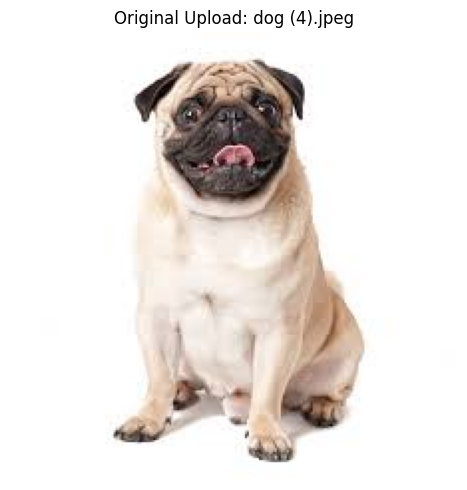

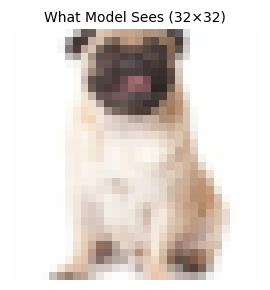

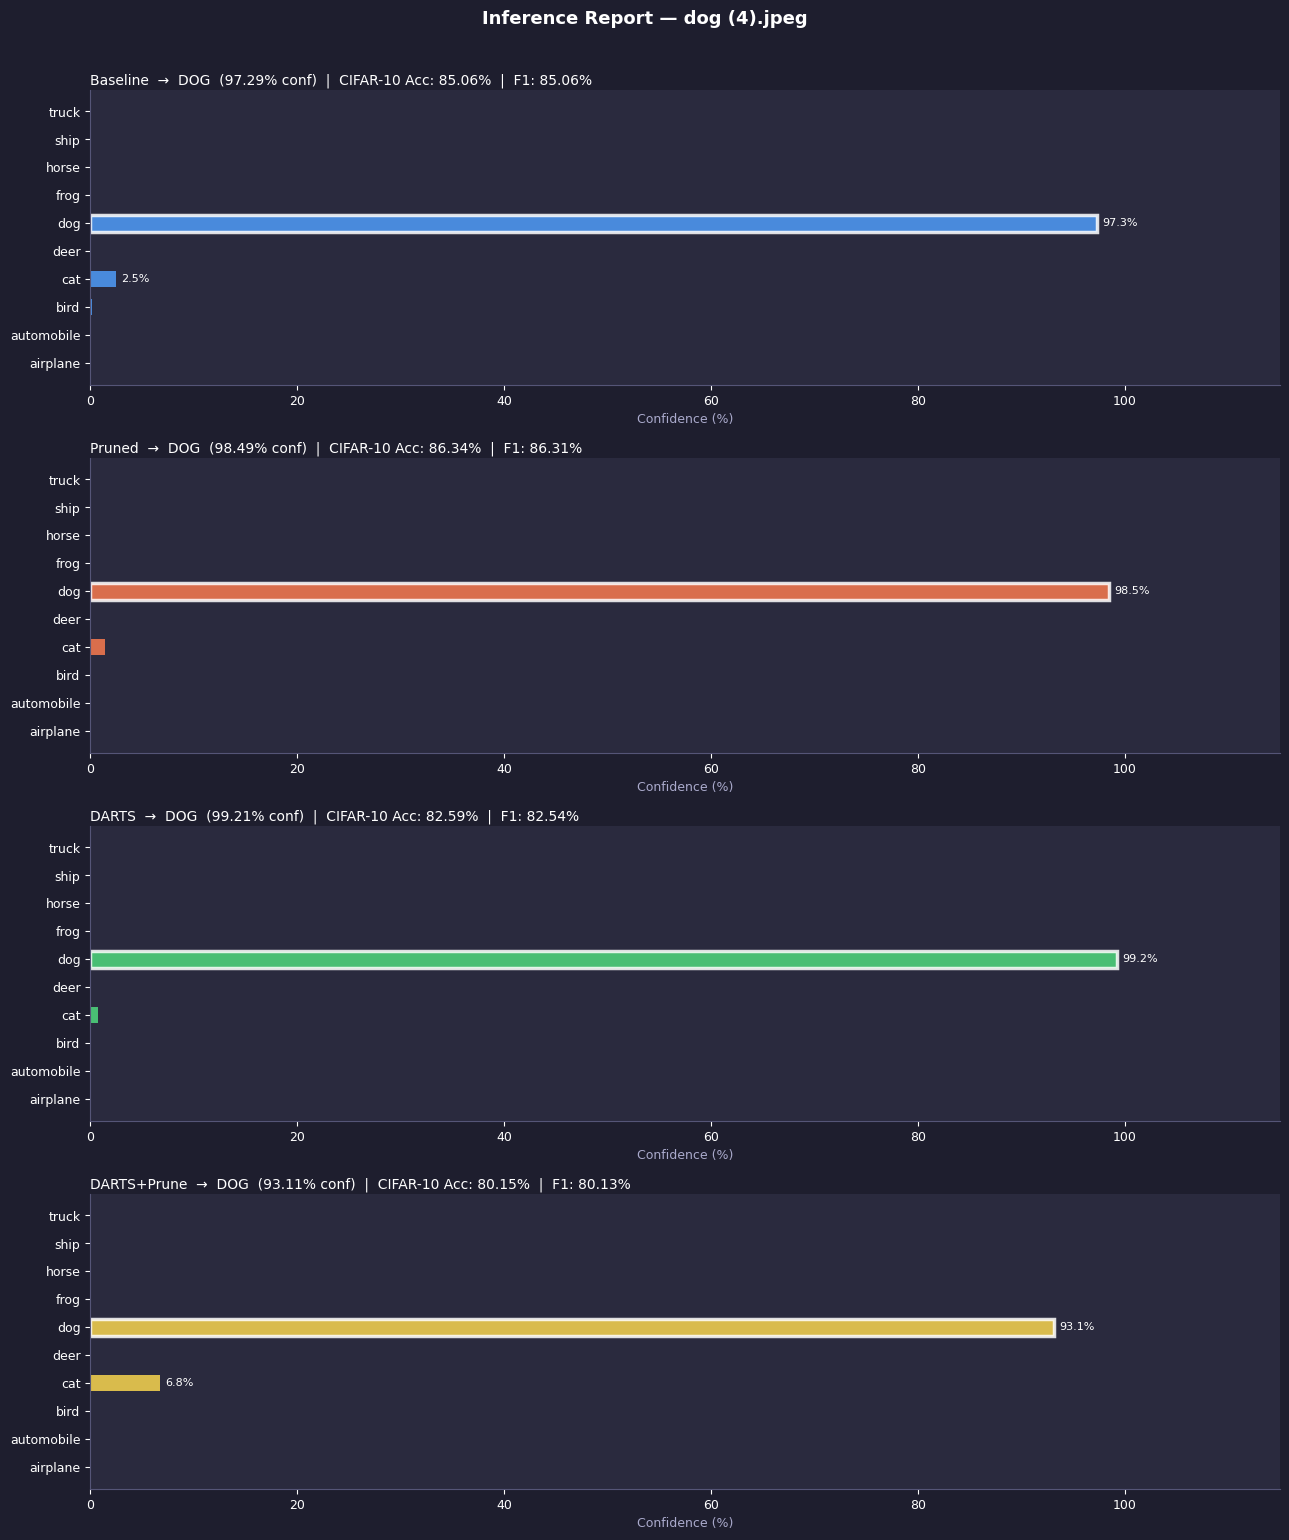

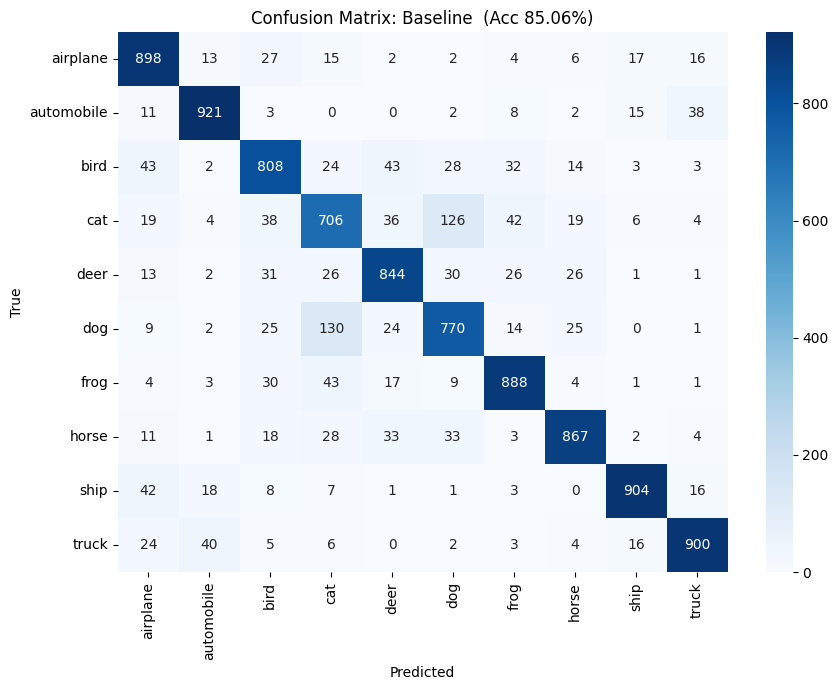

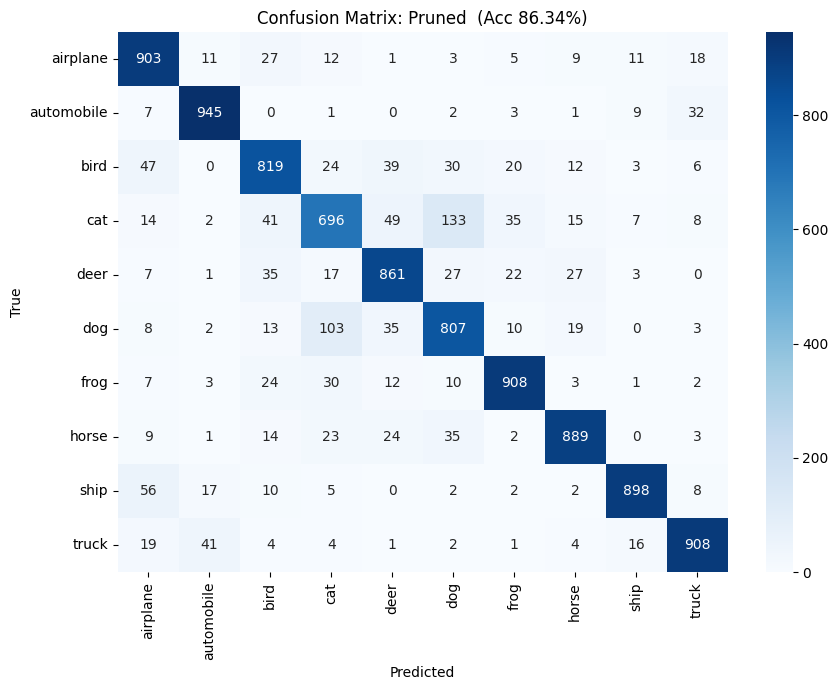

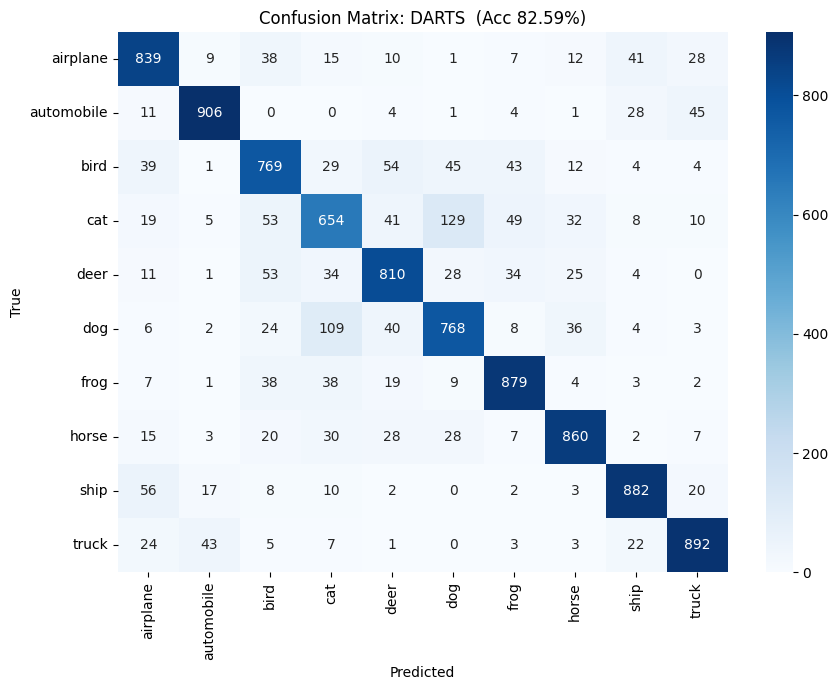

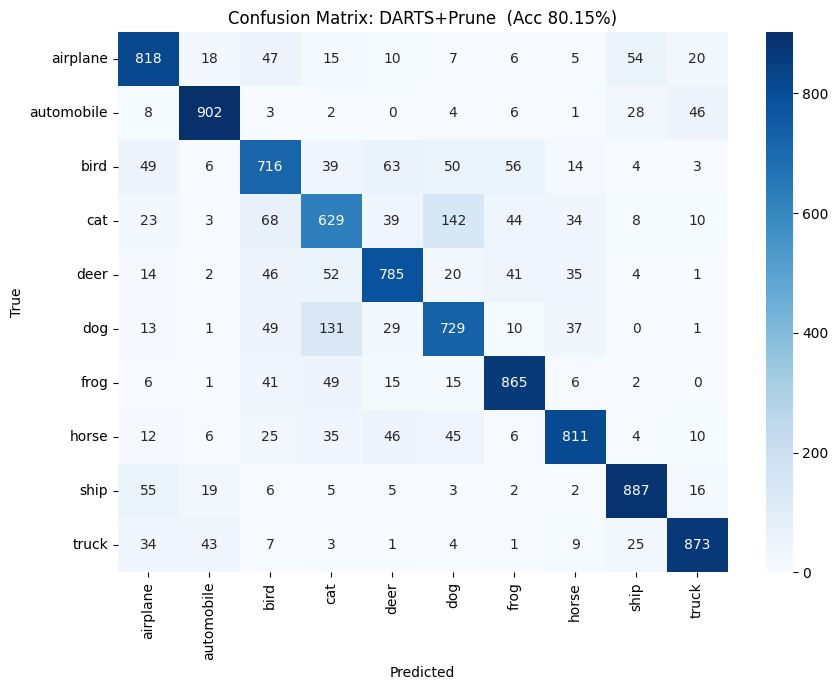

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms, models, datasets
from google.colab import files
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

# ==============================================================================
# SMART PREPROCESSING
# ==============================================================================
smart_inference_transform = transforms.Compose([
    transforms.Resize(40),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# ==============================================================================
# DARTS ARCHITECTURE  (shape-parametric — every channel count is an argument)
# ==============================================================================

class SepConv(nn.Module):
    """Double depthwise-separable conv. C_mid = actual pruned channel count."""
    def __init__(self, C_in, C_mid, C_out, kernel_size, stride, padding, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in,  C_in,  kernel_size, stride,  padding, groups=C_in,  bias=False),
            nn.Conv2d(C_in,  C_mid, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_mid, affine=affine),
            nn.ReLU(inplace=False),
            nn.Conv2d(C_mid, C_mid, kernel_size, 1, padding, groups=C_mid, bias=False),
            nn.Conv2d(C_mid, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )
    def forward(self, x): return self.op(x)

class PoolBN(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding):
        super().__init__()
        self.op = nn.Sequential(
            nn.MaxPool2d(kernel_size, stride=stride, padding=padding),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out)
        )
    def forward(self, x): return self.op(x)

class DARTSFinalNetwork(nn.Module):
    """
    Genotype-driven network.  channel_overrides is an optional dict
    {layer_index: actual_out_channels} read from the pruned checkpoint.
    Without overrides it behaves identically to the original architecture.
    """
    def __init__(self, genotype, init_channels=16, num_classes=10,
                 channel_overrides=None):
        super().__init__()
        self.genotype = genotype
        channel_overrides = channel_overrides or {}

        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True)
        )

        layers = []
        C_curr = init_channels
        reduce_at = {len(genotype) // 3, 2 * len(genotype) // 3}

        for i, op_name in enumerate(genotype):
            stride = 2 if i in reduce_at else 1
            C_nominal = C_curr if stride == 1 else C_curr * 2
            C_out = channel_overrides.get(i, C_nominal)

            if op_name in ('sep_3x3', 'sep_5x5'):
                kernel  = 3 if op_name == 'sep_3x3' else 5
                padding = 1 if op_name == 'sep_3x3' else 2
                # C_mid is the actual intermediate channel count from the checkpoint
                C_mid = channel_overrides.get(f'{i}_mid', C_out)
                layers.append(SepConv(C_curr, C_mid, C_out, kernel, stride, padding))
            elif op_name == 'max_pool':
                layers.append(PoolBN(C_curr, C_out, 3, stride, 1))
            elif op_name == 'identity':
                layers.append(nn.Identity())
            else:
                raise ValueError(f"Unknown op: {op_name}")

            C_curr = C_out

        self.layers = nn.Sequential(*layers)
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layers(x)
        x = self.global_pooling(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# ==============================================================================
# SHAPE READER — infer per-layer channel counts from a DARTS state_dict
# ==============================================================================

def read_darts_channel_overrides(sd: dict, genotype: list) -> dict:
    """
    Walk the state_dict keys for each layer and extract the actual output
    channel count (and SepConv intermediate channel count) so we can build
    a DARTSFinalNetwork that perfectly matches a pruned checkpoint.

    Returns a dict suitable for the channel_overrides argument.
    """
    overrides = {}
    reduce_at = {len(genotype) // 3, 2 * len(genotype) // 3}

    for i, op_name in enumerate(genotype):
        prefix = f'layers.{i}.op'

        if op_name in ('sep_3x3', 'sep_5x5'):
            # op.2 is the first pointwise conv  → its output = C_mid
            # op.6 is the second pointwise conv → its output = C_out
            mid_key = f'{prefix}.2.weight'
            out_key = f'{prefix}.6.weight'
            if mid_key in sd:
                overrides[f'{i}_mid'] = sd[mid_key].shape[0]
            if out_key in sd:
                overrides[i] = sd[out_key].shape[0]

        elif op_name == 'max_pool':
            # op.1 is the 1×1 pointwise conv → its output = C_out
            out_key = f'{prefix}.1.weight'
            if out_key in sd:
                overrides[i] = sd[out_key].shape[0]

        # identity has no weights; skip

    # classifier input = last layer's output channels
    if 'classifier.weight' in sd:
        pass   # already correct in the state_dict

    return overrides

# ==============================================================================
# EFFICIENTNET-B0 BUILDER
# ==============================================================================

def get_efficientnet_b0(num_classes=10):
    m = models.efficientnet_b0(pretrained=False)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

# ==============================================================================
# SHARED UTILITIES
# ==============================================================================

def _strip_thop(sd):
    """Remove thop profiling keys (substring match handles top-level keys too)."""
    return {k: v for k, v in sd.items()
            if 'total_ops' not in k and 'total_params' not in k}

def set_module_by_path(model, path, new_module):
    parts = path.split('.')
    parent = model
    for part in parts[:-1]:
        parent = parent[int(part)] if part.isdigit() else getattr(parent, part)
    final = parts[-1]
    if final.isdigit():
        parent[int(final)] = new_module
    else:
        setattr(parent, final, new_module)

def get_module_by_path(model, path):
    obj = model
    for p in path.split('.'):
        obj = obj[int(p)] if p.isdigit() else getattr(obj, p)
    return obj

# ==============================================================================
# SHAPE-AWARE EFFICIENTNET REBUILDER
# ==============================================================================

def rebuild_efficientnet_from_checkpoint(sd: dict) -> nn.Module:
    """
    Build an EfficientNet-B0 whose every layer shape exactly matches sd,
    then load sd with strict=True.
    """
    model = get_efficientnet_b0(10)

    for param_key, param_val in sd.items():
        if '.' not in param_key:
            continue
        mod_path, attr_name = param_key.rsplit('.', 1)
        if attr_name not in ('weight', 'bias'):
            continue
        try:
            mod = get_module_by_path(model, mod_path)
        except (AttributeError, IndexError, TypeError):
            continue
        current_attr = getattr(mod, attr_name, None)
        if current_attr is None or current_attr.shape == param_val.shape:
            continue

        if isinstance(mod, nn.Conv2d) and attr_name == 'weight':
            out_ch = param_val.shape[0]
            in_ch_per_group = param_val.shape[1]
            if mod.groups > 1:
                groups, in_ch = out_ch, out_ch
            else:
                groups, in_ch = 1, in_ch_per_group
            set_module_by_path(model, mod_path, nn.Conv2d(
                in_ch, out_ch, mod.kernel_size, mod.stride,
                mod.padding, mod.dilation, groups, mod.bias is not None
            ))
        elif isinstance(mod, nn.BatchNorm2d) and attr_name == 'weight':
            set_module_by_path(model, mod_path,
                nn.BatchNorm2d(param_val.shape[0], eps=mod.eps, momentum=mod.momentum))
        elif isinstance(mod, nn.Linear) and attr_name == 'weight':
            out_f, in_f = param_val.shape
            set_module_by_path(model, mod_path,
                nn.Linear(in_f, out_f, bias=(mod.bias is not None)))

    model.load_state_dict(sd, strict=True)
    return model

# ==============================================================================
# SAFE MODEL LOADER — auto-detects EfficientNet vs DARTS, handles pruning
# ==============================================================================

FALLBACK_GENOTYPE = ['sep_3x3', 'max_pool', 'max_pool',
                     'max_pool', 'sep_5x5', 'sep_5x5']
_discovered_genotype = None

def safe_load_model(path, num_classes=10):
    global _discovered_genotype

    if not os.path.exists(path):
        print(f"    ⚠️  Not found: {path}")
        return None

    try:
        raw = torch.load(path, map_location='cpu')

        # ── Unpack ───────────────────────────────────────────────────────────
        if isinstance(raw, dict) and 'state_dict' in raw:
            genotype   = raw.get('genotype', None)
            state_dict = _strip_thop(raw['state_dict'])
        else:
            genotype   = None
            state_dict = _strip_thop(raw)

        # ── Decide architecture ──────────────────────────────────────────────
        is_darts = any('stem' in k or 'layers.' in k for k in state_dict.keys())

        if is_darts:
            # Resolve genotype
            if genotype is None:
                # darts_pruned_finetuned.pth is always saved as a flat state_dict
                # (torch.save(best_state, path)) — no genotype key is expected.
                genotype = _discovered_genotype or FALLBACK_GENOTYPE
            else:
                _discovered_genotype = genotype

            # Read actual channel shapes from the checkpoint  ← THE KEY FIX
            overrides = read_darts_channel_overrides(state_dict, genotype)

            model = DARTSFinalNetwork(genotype, 16, num_classes,
                                      channel_overrides=overrides)
            # strict=True now works because architecture matches exactly
            model.load_state_dict(state_dict, strict=True)
            return model.to(DEVICE)

        else:
            # EfficientNet-B0 (baseline or pruned)
            model = rebuild_efficientnet_from_checkpoint(state_dict)
            return model.to(DEVICE)

    except Exception as e:
        print(f"\n    ❌  Load error: {e}")
        return None

# ==============================================================================
# EVALUATION
# ==============================================================================

def evaluate_on_cifar10(model, testloader):
    model.eval()
    preds_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in testloader:
            out = model(imgs.to(DEVICE))
            preds_list.extend(out.argmax(1).cpu().numpy())
            labels_list.extend(labels.numpy())
    acc = (np.array(preds_list) == np.array(labels_list)).mean() * 100
    f1  = f1_score(labels_list, preds_list, average='weighted') * 100
    cm  = confusion_matrix(labels_list, preds_list)
    return acc, f1, cm

# ==============================================================================
# VISUALIZATION
# ==============================================================================

def plot_full_report(all_metrics, img_orig, img_tensor, img_name):
    # Original upload
    plt.figure(figsize=(5, 5))
    plt.imshow(img_orig)
    plt.title(f"Original Upload: {img_name}", fontsize=12)
    plt.axis('off'); plt.tight_layout(); plt.show()

    # 32×32 model view
    plt.figure(figsize=(3, 3))
    view = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
    view = np.clip(np.array(view) * np.array(CIFAR_STD) + np.array(CIFAR_MEAN), 0, 1)
    plt.imshow(view)
    plt.title("What Model Sees (32×32)", fontsize=10)
    plt.axis('off'); plt.tight_layout(); plt.show()

    # Per-class confidence bars
    colours = ['#4f9cf9', '#f97b4f', '#4fd97e', '#f9d54f']
    fig, axes = plt.subplots(len(all_metrics), 1,
                             figsize=(13, 3.8 * len(all_metrics)))
    if len(all_metrics) == 1:
        axes = [axes]
    fig.patch.set_facecolor('#1e1e2e')

    for ax, col, (name, m) in zip(axes, colours, all_metrics.items()):
        probs = m['all_probs'] * 100
        bars  = ax.barh(CIFAR10_CLASSES, probs, color=col, alpha=0.85, height=0.6)
        pred_idx = CIFAR10_CLASSES.index(m['pred_class'])
        bars[pred_idx].set_edgecolor('white')
        bars[pred_idx].set_linewidth(2.5)
        for bar, val in zip(bars, probs):
            if val > 1.5:
                ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                        f'{val:.1f}%', va='center', color='white', fontsize=8)
        ax.set_facecolor('#2a2a3e')
        ax.set_xlim(0, 115)
        ax.set_title(
            f"{name}  →  {m['pred_class'].upper()}  ({m['confidence']:.2f}% conf)  |  "
            f"CIFAR-10 Acc: {m['acc']:.2f}%  |  F1: {m['f1']:.2f}%",
            color='white', fontsize=10, loc='left', pad=4
        )
        ax.tick_params(colors='white', labelsize=9)
        for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
        for sp in ['bottom', 'left']: ax.spines[sp].set_color('#555577')
        ax.set_xlabel('Confidence (%)', color='#aaaacc', fontsize=9)

    plt.suptitle(f'Inference Report — {img_name}',
                 color='white', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    # Confusion matrices
    for name, m in all_metrics.items():
        plt.figure(figsize=(9, 7))
        sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues',
                    xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
        plt.title(f"Confusion Matrix: {name}  (Acc {m['acc']:.2f}%)", fontsize=12)
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout(); plt.show()

# ==============================================================================
# MAIN
# ==============================================================================

if __name__ == "__main__":

    print("📦  Loading CIFAR-10 test set …")
    testloader = torch.utils.data.DataLoader(
        datasets.CIFAR10("./data", train=False, download=True,
                         transform=test_transform),
        batch_size=128, num_workers=2, pin_memory=True
    )

    model_paths = {
        "Baseline":    "models/baseline_efficientnet_b0.pth",
        "Pruned":      "models/pruned_efficientnet_b0_finetuned.pth",
        "DARTS":       "models/darts_final_network.pth",
        "DARTS+Prune": "models/darts_pruned_finetuned.pth",
    }

    print("\n📤  UPLOAD IMAGE")
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded. Exiting."); exit()

    img_name   = list(uploaded.keys())[0]
    img_orig   = Image.open(img_name).convert('RGB')
    img_tensor = smart_inference_transform(img_orig).unsqueeze(0).to(DEVICE)

    all_results = {}
    print(f"\n{'='*90}")
    print(f"{'Model':<15} | {'Prediction':<12} | {'Conf (%)':<10} | {'Acc (%)':<9} | {'F1 (%)':<8}")
    print(f"{'-'*90}")

    for name, path in model_paths.items():
        print(f"  Loading {name} …", end=' ', flush=True)
        model = safe_load_model(path)
        if model is None:
            print("skipped.")
            continue

        model.eval()

        with torch.no_grad():
            logits = model(img_tensor)
            prob   = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()

        pred_idx   = int(prob.argmax())
        pred_class = CIFAR10_CLASSES[pred_idx]
        confidence = float(prob[pred_idx] * 100)

        acc, f1, cm = evaluate_on_cifar10(model, testloader)

        all_results[name] = {
            'pred_class': pred_class,
            'confidence': confidence,
            'all_probs' : prob,
            'acc'       : acc,
            'f1'        : f1,
            'cm'        : cm,
        }
        print(f"{pred_class:<12} | {confidence:<10.2f} | {acc:<9.2f} | {f1:<8.2f}")

    print('=' * 90)

    if all_results:
        plot_full_report(all_results, img_orig, img_tensor, img_name)
    else:
        print("\n❌  No models loaded. Check model_paths and .pth filenames.")